# STARE-PODS — Rendezvous Analytics

*Companion notebook for the video walkthrough. Everything runs live against
**AWS S3** (Parquet chunks) + **RDS Postgres** (the `PodsMetadata` catalog);
the granules were ingested beforehand, so this notebook only queries.*

**STARE-PODS** — the **STARE Parallel Optimized Data Store** — leverages the
STARE quad-tree hierarchy to partition and organize geospatial data, and thus
enables distributed parallel processing of native data without requiring
re-gridding, i.e. resampling and/or re-projection.

For this demo of the STARE-PODS prototype, swaths of level 1C data from four
microwave radiometers — GPM's **GMI**, DMSP's **SSMIS**, GCOM-W1's **AMSR2**,
and JPSS's **ATMS** — were decomposed at STARE quadfurcation level 4
(**QL4** — the only name used for it from here on). This results in 2048
pods, corresponding to 2048 QL4 STARE spherical
triangles, or *trixels*, each roughly 700 km on a side, or an area of about
250,000 km² on average. The decomposition extracts the data elements of each swath that
overlap a given QL4 trixel and packages them into a Parquet chunk file —
so a pod (a logical construct) contains data chunks from **all** the swaths
that overlap (non-empty intersect) with the pod area: a natural spatial
co-location.

During the decomposition, a database management system (PostgreSQL)
catalogues all necessary information to reconstitute the swath granule — the
chunk's granule and pod identities, its space-time extents, etc., as well as
the metadata of the original HDF/netCDF file. Because the database holds the
chunks' spatiotemporal information, it can serve as a cross-instrument
**rendezvous engine**. A **rendezvous** is, at first, a *pod-level candidate
co-observation*: two or more instruments in the same QL4 pod within a time
window **Δt** — not necessarily an exact data-element-level intersection.
STARE's hierarchy supports refining such candidates afterwards, down to the
data elements.

The store holds the **first quarter of 2025** — every Level 1C granule of
the four instruments from January 1 to March 31, about 7,400 granules
decomposed into 12.5 million chunks. Every part runs on that whole
quarter, with one set of time windows throughout — **Δt = 5, 10 and 30
minutes**. Parts 1, 2 and 6 are the statistics; Parts 3, 4 and 5 bring
them down to the ground: a rendezvous over **Virginia**, the orbit swaths
that make it, and a region query over the whole state.

1. **The temporal catalog** — a common spatiotemporal reference: every chunk knows *where* (its QL4 pod) and *when*
2. **Rendezvous analytics** — discovery from the catalog records alone, over the whole quarter
3. **Rendezvous over Virginia** — a region of interest becomes four pods: 12.5 million records down to some twenty thousand
4. **Rendezvous up close** — refinement to the data elements: all six passes over the pod, then the three that meet within 5 minutes
5. **Rendezvous over a region of interest** — data access: space and time in one query, only the matching chunks read
6. **Performance at scale** — the whole quarter, timed at four scopes


In [1]:
import time
_setup_t0 = time.perf_counter()          # so this setup cell is timed too
from IPython import get_ipython

# Per-cell timing: every later cell self-reports "⏱ cell [n] took X.XXs" and
# the summary cell at the end totals them. Registered by name so re-running
# this cell cannot stack duplicate hooks.
CELL_TIMINGS = {}
_cell_start = {}


def _time_pre(info):
    _cell_start['t0'] = time.perf_counter()


def _time_post(result):
    t0 = _cell_start.pop('t0', None)
    if t0 is None:                       # cell failed before pre_run_cell ran
        return
    elapsed = time.perf_counter() - t0
    CELL_TIMINGS[result.execution_count] = elapsed
    print(f"\u23f1  cell [{result.execution_count}] took {elapsed:.2f}s")


_ip = get_ipython()
for _event, _fn in (('pre_run_cell', _time_pre), ('post_run_cell', _time_post)):
    for _old in [f for f in _ip.events.callbacks[_event] if f.__name__ == _fn.__name__]:
        _ip.events.unregister(_event, _old)
    _ip.events.register(_event, _fn)
_cell_start['t0'] = _setup_t0

import logging
import re
import os
from contextlib import contextmanager
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from great_tables import loc, style, html
from great_tables import GT as _GT


def spanner(text):
    # a column-spanner label centred over its columns even in viewers that
    # drop the table's stylesheet (a plain align attribute survives)
    return html(f'<div align="center">{text}</div>')


def GT(frame, **kwargs):
    """great_tables.GT, house-styled: bold centered title, centered subtitle
    (inline styles, so the notebook viewer's own table CSS cannot override
    them), and plain-word column labels auto-capitalized — code identifiers
    such as t_start keep their spelling."""
    table = (_GT(frame, **kwargs)
             .tab_style(style=style.text(align='center', weight='bold'),
                        locations=loc.title())
             .tab_style(style=style.text(align='center'),
                        locations=loc.subtitle()))
    labels = {c: c[0].upper() + c[1:] for c in frame.columns
              if isinstance(c, str) and re.fullmatch(r'[a-z][a-z ]*', c)}
    if labels:
        table = table.cols_label(labels)
    return table

logging.getLogger('starepandas').setLevel(logging.WARNING)  # keep outputs clean

import starepandas
from starepandas.demo_lib import StarePodsDemo
from starepandas.staredataframe import parse_chunk_filename, sid_to_podcode
from starepandas.io.granules import (
    load_s3_catalog_summary, load_s3_metadata, load_s3_pod_occupancy,
    load_s3_temporal_catalog,
)
from starepandas.overlap import (
    rendezvous_events, overlap_matrix, overlap_pod_table, pod_drilldown,
    fold_instrument,
)
from starepandas.demo_plots import (
    SATELLITES as SWATH_SATELLITES, chunk_pixels, plot_pod_coverage,
    plot_region_cover, plot_region_result, plot_rendezvous, pod_trixels,
    swath_pixels,
)

CONFIG_PATH = os.path.join(
    os.path.dirname(os.path.abspath(starepandas.__file__)), ".config")
STORE_PREFIX = "s3://zarrpods/storage"          # the Q1-2025 bulk-store root (the holdings table's scan-group list)
WINDOWS = tuple(pd.Timedelta(minutes=m) for m in (5, 10, 30))   # the Δt windows, every part
STARE_LEVEL = 4
INSTRUMENTS = ["GMI", "SSMIS", "AMSR2", "ATMS"]


class StepTimer:
    """Sub-step stopwatch for one cell: ``with T.step(kind, what): ...``
    records wall-clock seconds per step, tagged by kind — ``query`` (the
    database or S3 listing answers), ``download`` (chunk bytes from S3),
    ``local`` (pandas / STARE work on this computer), ``plot`` (building a
    matplotlib figure) and ``display`` (rendering a table or figure into the
    notebook). ``T.table()`` shows the breakdown with per-kind totals."""

    def __init__(self):
        self.steps = []
        self.last = None

    @contextmanager
    def step(self, kind, what):
        t0 = time.perf_counter()
        yield
        self.last = time.perf_counter() - t0
        self.steps.append({'kind': kind, 'step': what, 'seconds': self.last})

    def frame(self):
        df = pd.DataFrame(self.steps)
        df['share'] = df['seconds'] / df['seconds'].sum()
        return df

    def table(self, title):
        df = self.frame()
        return (GT(df)
                .tab_header(title=title)
                .fmt_number(columns='seconds', decimals=2)
                .fmt_percent(columns='share', decimals=0)
                .cols_label(kind="", step="", seconds="Seconds", share="Share"))


def fmt_times(frame, columns=('t_start', 't_end'), fmt='%Y-%m-%d %H:%M:%S'):
    """Render timestamp columns as compact strings for table display."""
    out = frame.copy()
    for column in columns:
        out[column] = out[column].dt.strftime(fmt)
    return out


demo = StarePodsDemo(aws_config_path=CONFIG_PATH)


def minutes_of(dt):
    return int(dt.total_seconds() // 60)


⏱  cell [1] took 3.84s


## Data ingested in STARE-PODS

The store holds the **first quarter of 2025** for the four instruments —
every Level 1C granule of GMI, SSMIS, AMSR2 and ATMS from January 1 to
March 31, ATMS on all three of its satellites (Suomi NPP, NOAA-20, NOAA-21).
Level 1C means intercalibrated brightness temperatures (`Tc`) on the GPM
XCAL common calibration (channel counts below per the GPM V07 file
specification). Each granule is decomposed **scan group** by scan
group (a scan group is what the catalog calls a *dataset*: one instrument's
swath at one footprint size, `GMI_S1`, `SSMIS_S4`, …), so a granule of a
four-scan-group instrument yields four families of chunks.

Every fact in the table below is read straight back from the catalog and
aggregated **by the database**: a quarter is twelve million chunk records,
far more than a notebook should pull down in full — Part 2 will read just
four columns of them. The two operations are not alike: the holdings summary
is the database's one *full aggregation pass* over the whole catalog
(granules, chunks, pods and sensing spans per scan group and satellite) and
takes well over a minute, while Part 2's read of four indexed columns is a
lighter operation and takes less than a minute. The chunk file names preserve
the original granule identity, e.g.

`1C.F18.SSMIS.XCAL2021-V.20250101-S112813-E131004.078441.V07B`

(level · satellite · instrument · intercalibration · sensing span · orbit ·
product version), so each chunk's satellite is recoverable from its path.
The store is one bulk root plus two small 2025-01-01 test roots (16 granules,
21,404 chunks); every part of this notebook counts all three, so its totals
agree throughout.


In [2]:
# Two server-side views of the whole catalog, no chunk records transferred:
#   summary   — one row per storage root x scan group x satellite (a full pass over
#               the catalog: granules, chunks, pods, sensing span)
#   occupancy — chunks per scan group x pod (served from the covering index)
from IPython.display import HTML
from great_tables import html

T = StepTimer()
with T.step('query', 'catalog summary — the database\'s one full read of the quarter'):
    summary = load_s3_catalog_summary()
t_summary = T.last
with T.step('query', 'pod occupancy — chunks per scan group × pod, index-only'):
    occupancy = load_s3_pod_occupancy()
t_occupancy = T.last

with T.step('local', 'fold scan groups to instruments, cross-check the two views'):
    assert summary['chunks'].sum() == occupancy['chunks'].sum()   # one catalog, two views
    summary['instrument'] = summary['Dataset'].map(fold_instrument)
    occupancy['instrument'] = occupancy['Dataset'].map(fold_instrument)

SATELLITES = {'GPM': 'GPM Core Observatory', 'F18': 'DMSP F18', 'GCOMW1': 'GCOM-W1',
              'NPP': 'Suomi NPP', 'NOAA20': 'NOAA-20 (JPSS-1)', 'NOAA21': 'NOAA-21 (JPSS-2)'}
L1C_CHANNELS = {'GMI': 13, 'SSMIS': 11, 'AMSR2': 12, 'ATMS': 9}


def satellite_list(platforms):
    """Satellite names, comma-separated, continued on a second line after
    the second one so a three-satellite row (ATMS) keeps the table narrow."""
    order = ['GPM', 'F18', 'GCOMW1', 'NPP', 'NOAA20', 'NOAA21']          # launch order
    names = [SATELLITES.get(p, p) for p in sorted(platforms, key=lambda p: (order.index(p) if p in order else 99, p))]
    return ', '.join(names[:2]) + (',<br>' + ', '.join(names[2:]) if len(names) > 2 else '')


def granule_count(frame):
    """Granules in a summary slice. Every scan group of a granule is its own
    summary row, so a (root, satellite) is counted once — the widest of its
    scan groups — then summed: roots are disjoint, satellites differ."""
    return int(frame.groupby(['storage_root', 'platform'], dropna=False)['granules']
                    .max().sum())


with T.step('local', 'inventory rows per instrument (pandas over 42 + 32,624 rows)'):
    rows = []
    for instrument in INSTRUMENTS:
        sub = summary[summary['instrument'] == instrument]
        store_groups = sorted(d.split('_', 1)[1]
                              for d in sub.loc[sub['storage_root'] == STORE_PREFIX, 'Dataset'].unique())
        platforms = sorted(sub['platform'].dropna().unique())
        rows.append({
            'instrument': instrument,
            'satellites': satellite_list(platforms),
            'channels': L1C_CHANNELS[instrument],
            'scan_groups': f"{len(store_groups)} ({store_groups[0]}–{store_groups[-1]})",
            'granules': granule_count(sub),
            'chunks': int(sub['chunks'].sum()),
            'pods': occupancy.loc[occupancy['instrument'] == instrument, 'podcode'].nunique(),
        })
    inventory = pd.DataFrame(rows)
with T.step('display', 'render "STARE-PODS Holdings"'):
    display(HTML('<p style="text-align:center;margin:0.5em 0 0">'
                 'Period: 2025-01-01 to 2025-03-31 (2025Q1)</p>'))
    display(
        GT(inventory)
        .tab_header(title="STARE-PODS Holdings — 2025Q1 by Instrument",
                    subtitle=html(f"<b>{granule_count(summary):,} granules → "
                                  f"{summary['Dataset'].nunique()} scan groups → "
                                  f"{summary['chunks'].sum():,} chunks in "
                                  f"{occupancy['podcode'].nunique()} QL4 pods</b>"))
        .fmt_integer(columns=['granules', 'chunks'])
        .fmt_markdown(columns=['satellites'])
        .cols_label(channels="Channels", scan_groups="Scan groups")
    )

display(T.table("Processing Time of Each Step in this Holdings Cell"))


GT(_tbl_data=  instrument                                        satellites  channels  \
0        GMI                              GPM Core Observatory        13   
1      SSMIS                                          DMSP F18        11   
2      AMSR2                                           GCOM-W1        12   
3       ATMS  Suomi NPP, NOAA-20 (JPSS-1),<br>NOAA-21 (JPSS-2)         9   

  scan_groups  granules   chunks  pods  
0   2 (S1–S2)      1387   751129  1980  
1   4 (S1–S4)      1267  1898057  2048  
2   6 (S1–S6)      1310  2891241  2048  
3   4 (S1–S4)      3396  6911440  2048  , _body=<great_tables._gt_data.Body object at 0x14fcd0cb0>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='satellites', type=<ColInfoTypeEnum.default: 1>, column_label='Satellites', column_align='left', column_width=None), ColInfo(var='channels', type=<ColInfoTypeEnum.default: 1>, column_label='Channels', column_align='right', column_width=None), ColInfo(var='scan_groups', type=<ColInfoTypeEnum.default: 1>, column_label='Scan groups', column_align='left', column_width=None), ColInfo(var='granules', type=<ColInfoTypeEnum.default: 1>, column_label='Granules', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1563e6bd0>, _spanners=Spanners([]), _heading=Heading(title='STARE-PODS Holdings — 2025Q1 by Instrument', subtitle=Html(text='<b>7,360 granules → 16 scan groups → 12,451,867 chunks in 2048 QL4 pods</b>'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1563e6960>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x14c02e720>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1563e6930>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1563e60c0>, <great_tables._gt_data.FormatInfo object at 0x1563e5fd0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='norma

GT(_tbl_data=      kind                                               step     seconds  \
0    query  catalog summary — the database's one full read...  106.534982   
1    query  pod occupancy — chunks per scan group × pod, i...    5.347698   
2    local  fold scan groups to instruments, cross-check t...    0.016623   
3    local  inventory rows per instrument (pandas over 42 ...    0.015620   
4  display                       render "STARE-PODS Holdings"    0.015650   

      share  
0  0.951795  
1  0.047777  
2  0.000149  
3  0.000140  
4  0.000140  , _body=<great_tables._gt_data.Body object at 0x1563e6ae0>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1563e6a50>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Holdings Cell', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1563e5fa0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1563e6990>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1563e6090>, _formats=[<great_tables._gt_data.FormatInfo object at 0x14fcd0170>, <great_tables._gt_data.FormatInfo object at 0x1563e6150>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='

⏱  cell [2] took 111.94s


## Part 1 — The temporal catalog

When a granule is partitioned among QL4 pods, the catalog creates a record
for each resulting Parquet chunk. Each record includes the chunk's QL4 pod
code, scan group, and temporal extent (`t_start` and `t_end`), derived from
the earliest and latest **scan times of the data elements within the chunk**
— not from the granule filename. The pod code is the quaternary (base-4)
representation of a STARE spatial index, so it retains STARE's hierarchy —
each digit refines the previous, like a postal code — and supports efficient
spatial retrieval by index or index prefix.

The two tables summarize the quarter's 12.5 million catalog records by scan
group and by QL4 pod, including the least, median, and most populated pods.
(The last `t_end` runs a little past midnight into April 1: the granules are
2025Q1's, and one whose sensing span crosses the quarter's last midnight
carries its final scans with it.)
The aggregation is performed by the database, so only the summaries are
returned. This illustrates a core STARE-PODS capability: diverse observations
retain their native geometries while sharing a common, searchable
spatiotemporal reference. The pattern to notice in the occupancy table:
sparse near the equator, dense near the poles, and GMI absent from the
polar caps.


In [3]:
per_ds = (summary.groupby('Dataset', as_index=False)
          .agg(chunks=('chunks', 'sum'),
               first_start=('t_start', 'min'),
               last_end=('t_end', 'max')))
per_ds.insert(1, 'granules', per_ds['Dataset'].map(
    lambda d: granule_count(summary[summary['Dataset'] == d])))
per_ds.insert(3, 'pods', per_ds['Dataset'].map(
    occupancy.groupby('Dataset')['podcode'].nunique()))
per_ds.insert(0, 'instrument', per_ds['Dataset'].map(fold_instrument))   # row groups


# every scan group of an instrument shares its first t_start / last t_end:
# show each once, on the group's first row
shown = fmt_times(per_ds, ('first_start', 'last_end'))
repeat = shown.duplicated(['instrument', 'first_start', 'last_end'])
shown.loc[repeat, ['first_start', 'last_end']] = ''
temporal_table = (
    GT(shown,
       groupname_col='instrument', rowname_col='Dataset')
    .tab_header(title="Temporal Catalog per Scan Group for 2025Q1",
                subtitle=html(f"<b>Total {summary['chunks'].sum():,} chunks</b>"))
    .fmt_integer(columns=['granules', 'chunks'])
    .cols_label(first_start="First t_start", last_end="Last t_end")
    .tab_style(style=style.text(weight='bold'), locations=loc.row_groups())
)
display(temporal_table)


def locate(podcode):
    """Centre of a pod's trixel as 'lat, lon (band)' — the polar pods are
    split at the antimeridian, so use the geometry's centroid."""
    centre = pod_trixels([podcode]).union_all().centroid
    lat, lon = centre.y, centre.x
    band = ('polar' if abs(lat) > 66.5 else
            'mid-latitude' if abs(lat) > 23.5 else 'tropical')
    return (f"{abs(lat):.0f}°{'N' if lat >= 0 else 'S'} "
            f"{abs(lon):.0f}°{'E' if lon >= 0 else 'W'}, {band}")


pod_chunks = occupancy.groupby('podcode')['chunks'].sum()
pod_instruments = occupancy.groupby('podcode')['instrument'].nunique()
n_possible = 8 * 4 ** STARE_LEVEL            # 8 octants x 4^level trixels
emptiest = pod_chunks.idxmin()
median_pod = (pod_chunks - pod_chunks.median()).abs().idxmin()   # nearest to the median
busiest = pod_chunks.idxmax()
occupancy_q = pd.DataFrame([
    {'statistic': f'QL{STARE_LEVEL} pods on the globe', 'value': f'{n_possible}', 'where': '', 'geolocation': ''},
    {'statistic': 'Pods holding at least one chunk',
     'value': f'{len(pod_chunks)} ({len(pod_chunks) / n_possible:.0%})', 'where': '', 'geolocation': ''},
    {'statistic': 'Pods visited by all four instruments',
     'value': f'{int((pod_instruments == 4).sum())}', 'where': '', 'geolocation': ''},
    {'statistic': "Pods beyond the reach of GPM's 65° orbit",
     'value': f"{n_possible - occupancy.loc[occupancy['instrument'] == 'GMI', 'podcode'].nunique()}",
     'where': '', 'geolocation': 'the two polar caps'},
    {'statistic': 'Fewest chunks in a pod',
     'value': f'{pod_chunks.min():,}', 'where': emptiest, 'geolocation': locate(emptiest)},
    {'statistic': 'Median chunks per pod',
     'value': f'{pod_chunks.median():,.0f}', 'where': median_pod, 'geolocation': locate(median_pod)},
    {'statistic': 'Most chunks in one pod',
     'value': f'{pod_chunks.max():,}', 'where': busiest, 'geolocation': locate(busiest)},
])
occupancy_table = (
    GT(occupancy_q)
    .tab_header(title=f"Pod Occupancy at QL{STARE_LEVEL} for 2025Q1",
                subtitle=html(f"<b>How the {summary['chunks'].sum():,} chunks spread over the "
                              f"QL{STARE_LEVEL} pods</b>"))
    .cols_label(statistic="", value="Pods/chunks", where="Where", geolocation="Geolocation")
)
display(occupancy_table)


GT(_tbl_data=   instrument   Dataset  granules   chunks  pods          first_start  \
0       AMSR2  AMSR2_S1      1310   482886  2048  2025-01-01 00:32:38   
1       AMSR2  AMSR2_S2      1310   482482  2048                        
2       AMSR2  AMSR2_S3      1310   482435  2048                        
3       AMSR2  AMSR2_S4      1310   482380  2048                        
4       AMSR2  AMSR2_S5      1310   483095  2048                        
5       AMSR2  AMSR2_S6      1310   477963  2048                        
6        ATMS   ATMS_S1      3396  1728857  2048  2025-01-01 00:47:01   
7        ATMS   ATMS_S2      3396  1728848  2048                        
8        ATMS   ATMS_S3      3395  1727694  2048                        
9        ATMS   ATMS_S4      3395  1726041  2048                        
10        GMI    GMI_S1      1387   388731  1980  2025-01-01 00:37:21   
11        GMI    GMI_S2      1387   362398  1972                        
12      SSMIS  SSMIS_S1      1267   476257  2048  2025-01-01 01:17:03   
13      SSMIS  SSMIS_S2      1267   476075  2048                        
14      SSMIS  SSMIS_S3      1267   471149  2048                        
15      SSMIS  SSMIS_S4      1267   474576  2048                        

               last_end  
0   2025-04-01 01:07:27  
1                        
2                        
3                        
4                        
5                        
6   2025-04-01 00:59:04  
7                        
8                        
9                        
10  2025-04-01 00:33:47  
11                       
12  2025-04-01 00:41:51  
13                       
14                       
15                       , _body=<great_tables._gt_data.Body object at 0x108361280>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.row_group: 3>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='Dataset', type=<ColInfoTypeEnum.stub: 2>, column_label='Dataset', column_align='left', column_width=None), ColInfo(var='granules', type=<ColInfoTypeEnum.default: 1>, column_label='Granules', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1563e45f0>, _spanners=Spanners([]), _heading=Heading(title='Temporal Catalog per Scan Group for 2025Q1', subtitle=Html(text='<b>Total 12,451,867 chunks</b>'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1540aa4b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1540a82c0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocRowGroups(rows=None), grpname={'AMSR2', 'SSMIS', 'GMI', 'ATMS'}, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1540a9550>, _formats=[<great_tables._

GT(_tbl_data=                                  statistic        value    where  \
0                     QL4 pods on the globe         2048            
1           Pods holding at least one chunk  2048 (100%)            
2      Pods visited by all four instruments         1980            
3  Pods beyond the reach of GPM's 65° orbit           68            
4                    Fewest chunks in a pod        3,831  q130203   
5                     Median chunks per pod        4,730  q003110   
6                    Most chunks in one pod       26,367  q033313   

               geolocation  
0                           
1                           
2                           
3       the two polar caps  
4       8°N 47°E, tropical  
5  25°S 52°E, mid-latitude  
6         85°S 27°W, polar  , _body=<great_tables._gt_data.Body object at 0x1541c5d90>, _boxhead=Boxhead([ColInfo(var='statistic', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='Pods/chunks', column_align='right', column_width=None), ColInfo(var='where', type=<ColInfoTypeEnum.default: 1>, column_label='Where', column_align='left', column_width=None), ColInfo(var='geolocation', type=<ColInfoTypeEnum.default: 1>, column_label='Geolocation', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x108362720>, _spanners=Spanners([]), _heading=Heading(title='Pod Occupancy at QL4 for 2025Q1', subtitle=Html(text='<b>How the 12,451,867 chunks spread over the QL4 pods</b>'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1541c5e80>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1541c63c0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1541c6480>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True

⏱  cell [3] took 0.05s


## Part 2 — Rendezvous analytics

Once observations share STARE spatial indices, the same search can be applied to
gridded, swath, point, and other geospatial data. A rendezvous is defined here
as observations by two or more instruments within the same QL4 pod and a
specified time window, **Δt**. Candidate rendezvous can therefore be
discovered from catalog records alone, before any science-data chunks are
opened.

For the full first quarter of 2025, the analysis reads only four fields — QL4
pod code, scan group, `t_start`, and `t_end` — from 12.5 million catalog
records. A single in-memory workflow then compares 5-, 10-, and 30-minute
windows, constructs the 10-minute instrument-pair matrix, and identifies the
QL4 pod with the most 4-way rendezvous. The result demonstrates
metadata-first discovery at scale: STARE supplies a common spatial reference,
while the catalog limits costly data access to observations selected for
subsequent analysis.

How the counts are made. An **event** is one pass arriving in a pod while
other instruments are still present there, within Δt; **n** is how many
instruments are present at that moment, the arriving one included, and each
event is counted once, at its own n. A pod is listed under *n-way* when at
least n instruments were present together at some moment — so a pod with a
4-way rendezvous also appears under 3-way and 2-way. The pair matrix counts a
pod for a pair whenever both were present together — at least those two, so a
3-way pod counts for each of its pairs. The combination table counts, per combination, the arrivals that
completed or extended it — one of its instruments arriving while all the
others were already present — so a triple can outnumber one of its pairs when
the third instrument is usually the one arriving. Reading the matrix: AMSR2
and ATMS are near-co-orbiting and meet everywhere; GMI, whose 65° orbit
drifts through every local time, meets everyone in nearly every pod it
reaches; SSMIS's orbital plane keeps it apart from AMSR2 and ATMS.


In [4]:
T = StepTimer()
PART2_DT = WINDOWS[1]                           # 10 min: the window for the matrix + drill-down
PART2_MIN = minutes_of(PART2_DT)
with T.step('query', 'read 4 columns of the whole catalog — 12.5 M chunks'):
    quarter = load_s3_temporal_catalog()          # the whole store — all three roots, as every part
N_QUARTER = len(quarter)                          # Part 3's headline compares against it

window_rows = []
for dt in WINDOWS:
    minutes = minutes_of(dt)
    with T.step('local', f'find meetings + pod table at Δt = {minutes} min'):
        ev = rendezvous_events(quarter, dt)
        table = overlap_pod_table(ev)
    row = {'window': f"Δt = {minutes} min", 'events': len(ev)}
    for n in table.columns:
        row[f'{n}-way'] = int(table[n].gt(0).sum())
    window_rows.append(row)
    if dt == PART2_DT:
        q_events, q_pod_table = ev, table
    del ev, table
windows_table = pd.DataFrame(window_rows)
way_cols = [col for col in windows_table.columns if col.endswith('-way')]
windows_table[way_cols] = windows_table[way_cols].fillna(0).astype(int)
with T.step('display', 'render the Δt table'):
    display(
        GT(windows_table)
        .tab_header(title="Time-Window Dependence of Rendezvous")
        .fmt_integer(columns=['events'])
        .tab_spanner(label=spanner("QL4 Pods with an n-way Rendezvous"), columns=way_cols)
        .cols_label(window="", events="Events (all n)")
    )

with T.step('local', 'pair matrix over the quarter'):
    q_matrix = overlap_matrix(q_events).astype(object)
    for instrument in q_matrix.index:          # the diagonal is not a pairing
        q_matrix.loc[instrument, instrument] = '—'
    q_matrix.insert(0, 'instrument', q_matrix.index)
with T.step('display', 'render the matrix'):
    display(
        GT(q_matrix.reset_index(drop=True), rowname_col='instrument')
        .tab_header(title=f"Pairwise Rendezvous with a {PART2_MIN}-min Window")
    )

with T.step('local', 'find the pod with the most 4-way rendezvous, drill into it'):
    widest_q = max(q_pod_table.columns)
    n_quad = int(q_pod_table[widest_q].gt(0).sum())
    q_events['width'] = q_events['instruments'].map(len)
    quad_counts = q_events.loc[q_events['width'] == widest_q, 'podcode'].value_counts()
    quad_pod = quad_counts.index[0]
    q_drill = pod_drilldown(q_events, quad_pod).drop(columns='times')
    q_drill = q_drill.assign(instruments=q_drill['instruments'].map(' + '.join))
with T.step('display', 'render the drill-down'):
    display(
        GT(q_drill)
        .tab_header(title=f"Rendezvous of All Instrument Combinations in Pod {quad_pod}")
        .cols_label(instruments="Combination", n_instruments="n",
                    frequency="Rendezvous")
        # left-aligned throughout, like the two tables above it
        .cols_align(align='left', columns=['instruments', 'n_instruments', 'frequency'])
    )
del quarter
display(T.table("Processing Time of Each Step in this Part 2 Cell"))


GT(_tbl_data=        window   events  2-way  3-way  4-way
0   Δt = 5 min  1499727   2048   1414     19
1  Δt = 10 min  2338290   2048   1983     65
2  Δt = 30 min  5104738   2048   2048    390, _body=<great_tables._gt_data.Body object at 0x47bf5a7b0>, _boxhead=Boxhead([ColInfo(var='window', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events (all n)', column_align='right', column_width=None), ColInfo(var='2-way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='3-way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='4-way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1563e52b0>, _spanners=Spanners([SpannerInfo(spanner_id='<div align="center">QL4 Pods with an n-way Rendezvous</div>', spanner_level=0, spanner_label=Html(text='<div align="center">QL4 Pods with an n-way Rendezvous</div>'), spanner_units=None, spanner_pattern=None, vars=['2-way', '3-way', '4-way'], built=None)]), _heading=Heading(title='Time-Window Dependence of Rendezvous', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x47bf58fb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x47bf59130>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x47bf599d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1563e6630>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', valu

GT(_tbl_data=  instrument AMSR2  ATMS   GMI SSMIS
0      AMSR2     —  2048  1976   473
1       ATMS  2048     —  1980   653
2        GMI  1976  1980     —  1963
3      SSMIS   473   653  1963     —, _body=<great_tables._gt_data.Body object at 0x154455b80>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.stub: 2>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='AMSR2', type=<ColInfoTypeEnum.default: 1>, column_label='AMSR2', column_align='left', column_width=None), ColInfo(var='ATMS', type=<ColInfoTypeEnum.default: 1>, column_label='ATMS', column_align='left', column_width=None), ColInfo(var='GMI', type=<ColInfoTypeEnum.default: 1>, column_label='GMI', column_align='left', column_width=None), ColInfo(var='SSMIS', type=<ColInfoTypeEnum.default: 1>, column_label='SSMIS', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1544558e0>, _spanners=Spanners([]), _heading=Heading(title='Pairwise Rendezvous with a 10-min Window', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x154457c50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1544559a0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x154454680>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsI

GT(_tbl_data=                   instruments  n_instruments  frequency
0                 AMSR2 + ATMS              2       4975
1                  AMSR2 + GMI              2        117
2                AMSR2 + SSMIS              2       2459
3                   ATMS + GMI              2        184
4                 ATMS + SSMIS              2       3693
5                  GMI + SSMIS              2        100
6           AMSR2 + ATMS + GMI              3        117
7         AMSR2 + ATMS + SSMIS              3       3295
8          AMSR2 + GMI + SSMIS              3         73
9           ATMS + GMI + SSMIS              3        101
10  AMSR2 + ATMS + GMI + SSMIS              4         87, _body=<great_tables._gt_data.Body object at 0x154457fe0>, _boxhead=Boxhead([ColInfo(var='instruments', type=<ColInfoTypeEnum.default: 1>, column_label='Combination', column_align='left', column_width=None), ColInfo(var='n_instruments', type=<ColInfoTypeEnum.default: 1>, column_label='n', column_align='left', column_width=None), ColInfo(var='frequency', type=<ColInfoTypeEnum.default: 1>, column_label='Rendezvous', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x154454ef0>, _spanners=Spanners([]), _heading=Heading(title='Rendezvous of All Instrument Combinations in Pod q033303', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x154454bf0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x154455100>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x154457d70>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_

GT(_tbl_data=      kind                                               step    seconds  \
0    query  read 4 columns of the whole catalog — 12.5 M c...  38.807125   
1    local            find meetings + pod table at Δt = 5 min  12.747786   
2    local           find meetings + pod table at Δt = 10 min  12.521712   
3    local           find meetings + pod table at Δt = 30 min  13.020062   
4  display                                render the Δt table   0.007487   
5    local                       pair matrix over the quarter   1.267218   
6  display                                  render the matrix   0.006178   
7    local  find the pod with the most 4-way rendezvous, d...   0.425094   
8  display                              render the drill-down   0.004593   

      share  
0  0.492431  
1  0.161759  
2  0.158890  
3  0.165214  
4  0.000095  
5  0.016080  
6  0.000078  
7  0.005394  
8  0.000058  , _body=<great_tables._gt_data.Body object at 0x154456300>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x14f2e5640>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 2 Cell', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x154456120>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x154456210>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x154455550>, _formats=[<great_tables._gt_data.FormatInfo object at 0x154454560>, <great_tables._gt_data.FormatInfo object at 0x1544548f0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', v

⏱  cell [4] took 78.85s


## Part 3 — Rendezvous over Virginia

Part 2 analyzed rendezvous globally. Part 3 narrows the analysis to Virginia
to demonstrate how STARE converts a region of interest into a small,
indexable working set. At QL4, Virginia's STARE cover consists of four pods;
the largest contains approximately half of the state, from Richmond to the
coast. Because every catalog record carries a QL4 pod code, the analysis
retrieves only the chunk records associated with those four pods — some
twenty thousand — rather than searching all 12.5 million. No science-data chunks are
opened for this screening step. **That reduction is the headline: the catalog
excludes well over 99% of the quarter before any science data is opened.**

The first figure shows Virginia and its four-pod QL4 cover. The cover is
visibly larger than the state, and that is expected at this resolution: a
QL4 trixel is roughly 700 km on a side, so a four-trixel cover necessarily
extends well beyond Virginia. Each quadfurcation — QL5, QL6 and deeper —
halves the characteristic linear scale, so a deeper cover conforms
progressively more closely to the state boundary, at the cost of more
trixels. QL4 is this demonstration's storage and initial-query level.

The first table reports, for each Virginia cover pod, its share of the state,
its chunk-record count, and how many rendezvous events it holds at each of
the 5-, 10- and 30-minute windows, split by how many instruments were
present (each event counted once, at its own n). The results reflect the satellites' orbit
characteristics: **no 4-way rendezvous occurred over Virginia during the
quarter**, even at 30 minutes, whereas 3-way rendezvous occurred within **5
minutes**. The remainder of the notebook follows the first **3-way**
rendezvous within 5 minutes in the pod covering the largest share of
Virginia — AMSR2, GMI and ATMS on February 8, 2025.

To place that event in orbital context, the second table identifies the
nearest pass over the selected pod for each of the **six satellites**
represented in the catalog. Each pass occurs within 75 minutes of the
rendezvous. Together they represent all four instruments, including ATMS on
Suomi NPP, NOAA-20 and NOAA-21; the table marks the three passes that form
the 5-minute rendezvous. We first used STARE to represent Virginia at QL4;
the two maps that follow place that common indexed region in the context of
each swath's footprint on the pod grid — the QL4 pods its chunks occupy, one
panel per swath, first around the globe for orbital context, then zoomed in
on the eastern United States, with Virginia's outline, its four cover pods
outlined and the selected pod in black. The
comparison shows how a common STARE index makes disparate swaths directly
searchable and comparable without first regridding them. Throughout the
figures each instrument keeps one colour — ATMS orange, AMSR2 blue, GMI red,
SSMIS green — and every swath is also labelled directly.


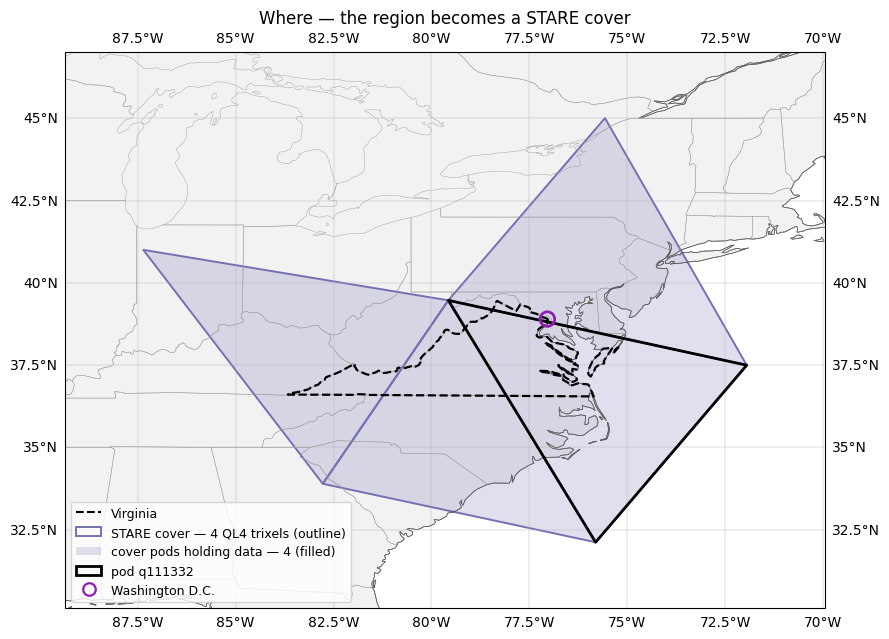

GT(_tbl_data=               pod    virginia       records              window  \
0          q111301         35%         4,701          Δt = 5 min   
1                                                    Δt = 10 min   
2                                                    Δt = 30 min   
3          q111303         13%         5,253          Δt = 5 min   
4                                                    Δt = 10 min   
5                                                    Δt = 30 min   
6   <b>q111332</b>  <b>50%</b>  <b>5,064</b>   <b>Δt = 5 min</b>   
7                                             <b>Δt = 10 min</b>   
8                                             <b>Δt = 30 min</b>   
9          q111333          3%         5,198          Δt = 5 min   
10                                                   Δt = 10 min   
11                                                   Δt = 30 min   

           2-way      3-way     4-way  
0            373         10         0  
1            590         14         0  
2          1,470         80         0  
3            429         10         0  
4            695         35         0  
5          1,653        124         0  
6     <b>440</b>   <b>6</b>  <b>0</b>  
7     <b>721</b>   <b>9</b>  <b>0</b>  
8   <b>1,642</b>  <b>84</b>  <b>0</b>  
9            462          4         0  
10           721         12         0  
11         1,673         95         0  , _body=<great_tables._gt_data.Body object at 0x47bf45b80>, _boxhead=Boxhead([ColInfo(var='pod', type=<ColInfoTypeEnum.default: 1>, column_label='Pod', column_align='left', column_width=None), ColInfo(var='virginia', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Share of<br>Virginia'), column_align='left', column_width=None), ColInfo(var='records', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Chunk<br>records'), column_align='left', column_width=None), ColInfo(var='window', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='2-way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='left', column_width=None), ColInfo(var='3-way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='left', column_width=None), ColInfo(var='4-way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x47bf9e480>, _spanners=Spanners([SpannerInfo(spanner_id='<div align="center">Events, by Instruments Present</div>', spanner_level=0, spanner_label=Html(text='<div align="center">Events, by Instruments Present</div>'), spanner_units=None, spanner_pattern=None, vars=['2-way', '3-way', '4-way'], built=None)]), _heading=Heading(title="Rendezvous in Virginia's QL4 Pods, 2025Q1", subtitle=Html(text='<b>20,216 chunk records in 4 pods</b>'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1563e6f00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1563e68d0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1563e4650>, _formats=[<great_tables._gt_data.FormatInfo object at 0x47bff4650>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=T

GT(_tbl_data=   order instrument  satellite   orbit      sensing pass_start  pass_end  \
0      1       ATMS    NOAA-20  037440  05:39–07:20   06:44:11  06:46:03   
1      2      AMSR2    GCOM-W1  067712  06:30–08:08   07:31:17  07:34:16   
2      3        GMI        GPM  062156  07:01–08:34   07:34:04  07:36:09   
3      4       ATMS    NOAA-21  011648  06:31–08:12   07:36:00  07:37:44   
4      5       ATMS  Suomi NPP  068836  06:57–08:39   08:01:37  08:02:17   
5      6      SSMIS   DMSP F18  078976  07:44–09:25   08:48:02  08:50:18   

   chunks member  
0       4  -51.8  
1       6      ✓  
2       2      ✓  
3       4      ✓  
4       4   25.6  
5       4   72.0  , _body=<great_tables._gt_data.Body object at 0x17302ad20>, _boxhead=Boxhead([ColInfo(var='order', type=<ColInfoTypeEnum.default: 1>, column_label='#', column_align='right', column_width=None), ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='satellite', type=<ColInfoTypeEnum.default: 1>, column_label='Satellite', column_align='left', column_width=None), ColInfo(var='orbit', type=<ColInfoTypeEnum.default: 1>, column_label='Orbit', column_align='right', column_width=None), ColInfo(var='sensing', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Granule time span<br>(UTC)'), column_align='left', column_width=None), ColInfo(var='pass_start', type=<ColInfoTypeEnum.default: 1>, column_label='Start', column_align='right', column_width=None), ColInfo(var='pass_end', type=<ColInfoTypeEnum.default: 1>, column_label='End', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Chunks<br>in pod'), column_align='right', column_width=None), ColInfo(var='member', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Missing by<br>(min)'), column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x17301f620>, _spanners=Spanners([SpannerInfo(spanner_id='<div align="center">Pass over the Pod</div>', spanner_level=0, spanner_label=Html(text='<div align="center">Pass over the Pod</div>'), spanner_units=None, spanner_pattern=None, vars=['pass_start', 'pass_end'], built=None)]), _heading=Heading(title='Orbit Swaths over Pod q111332 around the Example Rendezvous', subtitle=Html(text="<b>6 satellites, each one's pass nearest 2025-02-08 07:36:00 UTC</b> — the 3 marked ✓ rendezvous within Δt = 5 min"), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x17302b830>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x17302bd40>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x17302bd10>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=Optio

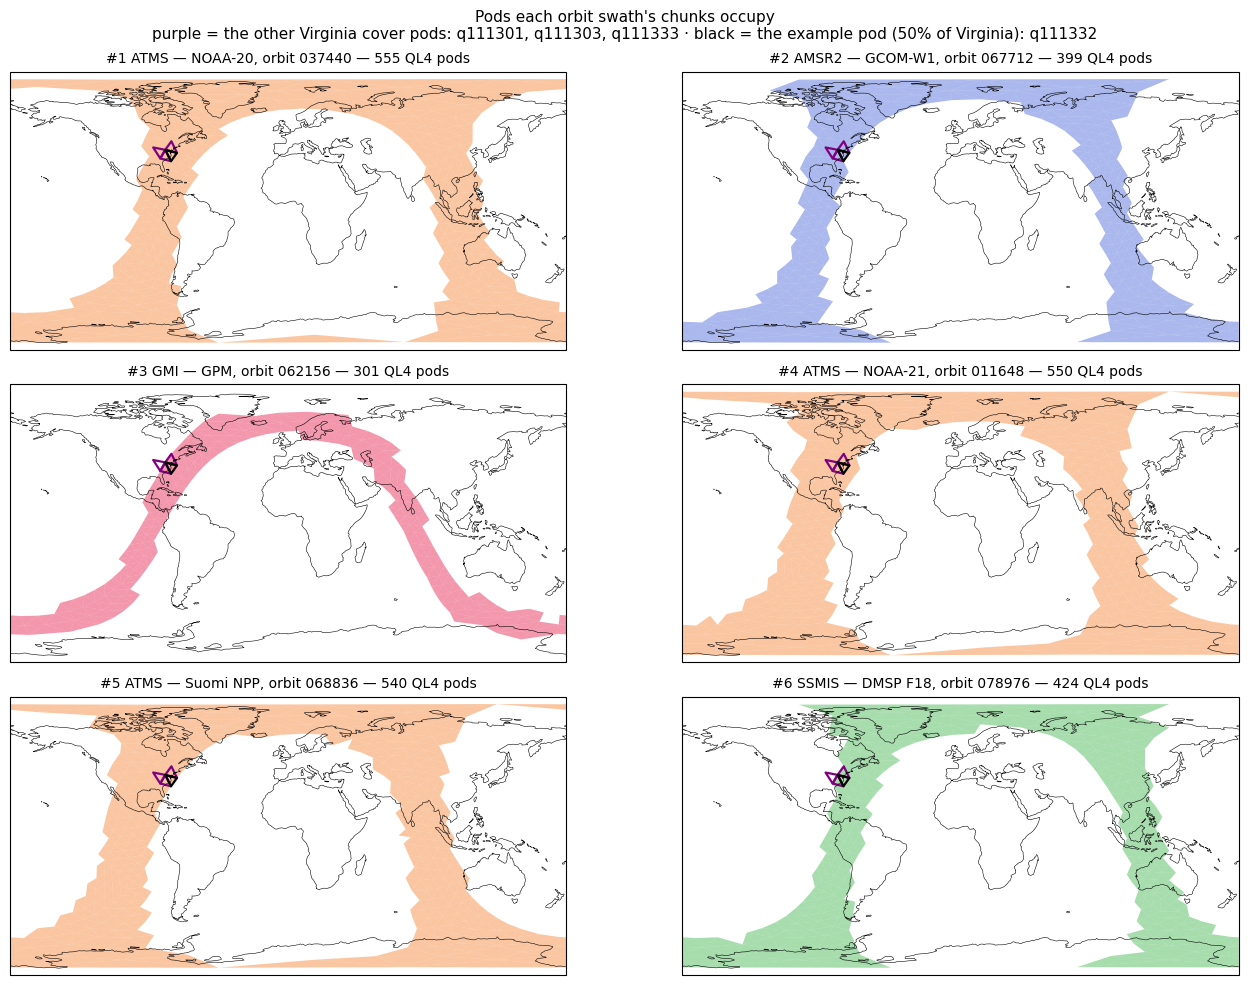

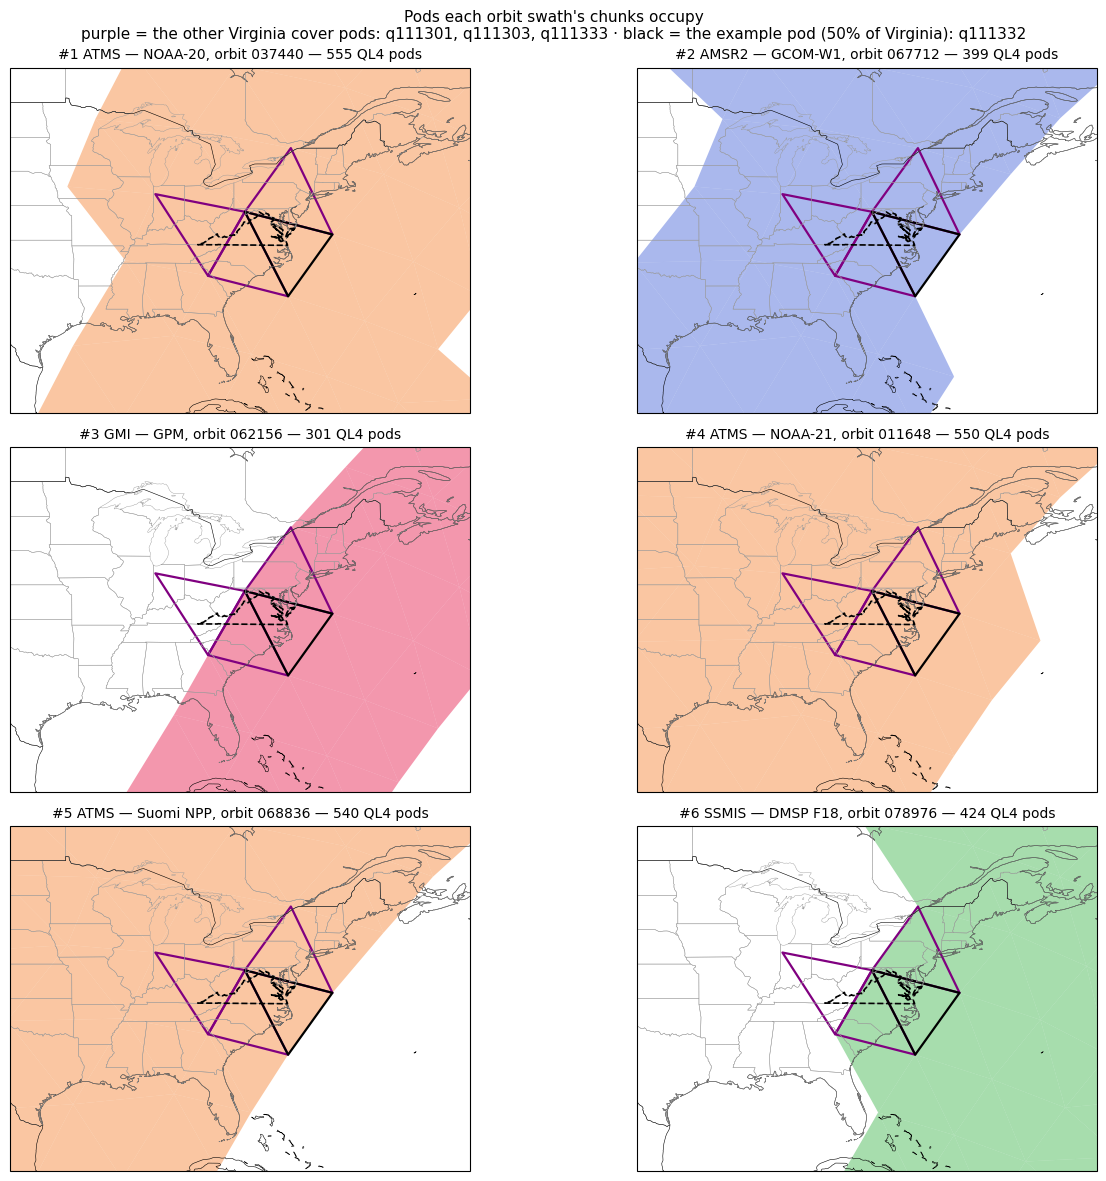

GT(_tbl_data=       kind                                               step   seconds  \
0     local  Virginia's boundary → its QL4 STARE cover; the...  0.146561   
1     query  catalog of the 4 Virginia pods, 2025Q1 — one r...  9.185794   
2   display  the headline — how much of the catalog the reg...  0.000872   
3      plot  build figure 1 — Virginia and its QL4 STARE co...  0.101922   
4   display                                    render figure 1  0.365130   
5     local   find meetings in the Virginia pods at Δt = 5 min  0.016756   
6     local  find meetings in the Virginia pods at Δt = 10 min  0.016312   
7     local  find meetings in the Virginia pods at Δt = 30 min  0.017176   
8     local               rendezvous per pod × window (pandas)  0.006279   
9   display                           render the per-pod table  0.016185   
10    local  pick the example: the first 3-way at the tight...  0.002282   
11    query  full metadata of every chunk, all pods, within...  1.912693   
12    local  each satellite's pass over the example pod nea...  0.108127   
13  display                             render the swath table  0.008701   
14    local  catalog rows of the six swaths, every pod they...  0.006971   
15     plot  build figure 2 — the six orbit swaths around t...  2.526286   
16  display                                    render figure 2  0.292050   
17     plot  build figure 3 — the same six swaths zoomed in...  2.592708   
18  display                                    render figure 3  0.357995   

       share  
0   0.008289  
1   0.519535  
2   0.000049  
3   0.005765  
4   0.020651  
5   0.000948  
6   0.000923  
7   0.000971  
8   0.000355  
9   0.000915  
10  0.000129  
11  0.108179  
12  0.006115  
13  0.000492  
14  0.000394  
15  0.142883  
16  0.016518  
17  0.146640  
18  0.020248  , _body=<great_tables._gt_data.Body object at 0x1741f0410>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1741f3980>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 3 Cell', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1741f0a40>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x17304fbc0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x17304ede0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1740ed9a0>, <great_tables._gt_data.FormatInfo object at 0x17419eab0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsI

⏱  cell [5] took 17.70s


In [5]:
T = StepTimer()
import numpy as np
import pystare
import cartopy.io.shapereader as shpreader
import geopandas
from starepandas.tools.spatial_conversions import sids_from_multipolygon

DC = {'lat': 38.9, 'lon': -77.04}                       # Washington D.C.
LOAD_SPAN = pd.Timedelta(hours=3)                       # catalog span loaded around the rendezvous (holds every nearby swath whole)

with T.step('local', 'Virginia\'s boundary → its QL4 STARE cover; the pod over Washington D.C.'):
    states = geopandas.read_file(shpreader.natural_earth(
        resolution='50m', category='cultural', name='admin_1_states_provinces_lakes'))
    virginia = states.loc[states['name'] == 'Virginia', 'geometry'].iloc[0]
    va_sids = sorted({int(s) for s in sids_from_multipolygon(virginia, STARE_LEVEL, force_ccw=True)})
    va_pods = sorted({sid_to_podcode(s) for s in va_sids})
    dc_pod = sid_to_podcode(int(pystare.from_latlon(
        np.array([DC['lat']]), np.array([DC['lon']]), STARE_LEVEL)[0]))
    assert dc_pod in va_pods
    # the share of Virginia's area inside each cover pod; the example follows the largest
    overlap = pd.Series({p: g.intersection(virginia).area / virginia.area
                         for p, g in zip(va_pods, pod_trixels(va_pods))})
    focus_pod = overlap.idxmax()
with T.step('query', f'catalog of the {len(va_pods)} Virginia pods, 2025Q1 — one read per pod code'):
    va_catalog = pd.concat([load_s3_temporal_catalog(podcode_prefix=p) for p in va_pods],
                           ignore_index=True)
with T.step('display', 'the headline — how much of the catalog the region excludes'):
    reduction = N_QUARTER / len(va_catalog)
    display(HTML('<div align="center"><p style="margin:0.8em 0"><b>Catalog-first discovery: '
                 f"the quarter's {N_QUARTER:,} chunk records → {len(va_catalog):,} for Virginia's "
                 f"{len(va_pods)} QL{STARE_LEVEL} pods — a {reduction:,.0f}× reduction, "
                 f"{1 - 1 / reduction:.2%} of the catalog excluded before any science data is opened"
                 '</b></p></div>'))
with T.step('plot', f'build figure 1 — Virginia and its QL{STARE_LEVEL} STARE cover, every cover pod holding data'):
    fig = plot_region_cover(None, va_sids, va_catalog, highlight_pod=focus_pod,
                            region=virginia, region_label='Virginia',
                            point=(DC['lon'], DC['lat']), point_label='Washington D.C.')
with T.step('display', 'render figure 1'):
    display(fig)
    plt.close(fig)

va_events = {}
for dt in WINDOWS:
    with T.step('local', f'find meetings in the Virginia pods at Δt = {minutes_of(dt)} min'):
        ev = rendezvous_events(va_catalog, dt)
        ev['n'] = ev['instruments'].map(len)
        va_events[dt] = ev

with T.step('local', 'rendezvous per pod × window (pandas)'):
    # one row per pod and window, so the table stays narrow on screen; the
    # pod's share and record count are shown once, on its first row
    counts = {dt: va_events[dt].groupby(['podcode', 'n']).size().unstack(fill_value=0)
              for dt in WINDOWS}
    n_records = va_catalog.groupby('podcode').size()
    rows = []
    for pod in va_pods:
        for k, dt in enumerate(WINDOWS):
            c = counts[dt]
            rows.append({'_pod': pod,
                         'pod': pod if k == 0 else '',
                         'virginia': f"{overlap[pod]:.0%}" if k == 0 else '',
                         'records': f"{n_records[pod]:,}" if k == 0 else '',
                         'window': f"Δt = {minutes_of(dt)} min",
                         **{f'{n}-way': (f"{int(c.loc[pod, n]):,}" if n in c.columns and pod in c.index else '0')
                            for n in (2, 3, 4)}})
    per_pod = pd.DataFrame(rows)
    # the example pod's rows in bold — a plain tag, so viewers that drop stylesheets keep it
    focus_rows = per_pod.index[per_pod['_pod'] == focus_pod]
    shown_cols = [c for c in per_pod.columns if c != '_pod']
    for col in shown_cols:
        per_pod.loc[focus_rows, col] = per_pod.loc[focus_rows, col].map(
            lambda v: f'<b>{v}</b>' if v != '' else '')
    per_pod = per_pod[shown_cols]
with T.step('display', 'render the per-pod table'):
    display(
        GT(per_pod)
        .tab_header(title="Rendezvous in Virginia's QL4 Pods, 2025Q1",
                    subtitle=html(f"<b>{len(va_catalog):,} chunk records in {len(va_pods)} pods</b>"))
        .fmt_markdown(columns=shown_cols)
        .tab_spanner(label=spanner("Events, by Instruments Present"), columns=['2-way', '3-way', '4-way'])
        .cols_label(pod="Pod", virginia=html("Share of<br>Virginia"), records=html("Chunk<br>records"), window="")
    )

with T.step('local', 'pick the example: the first 3-way at the tightest window in the pod covering most of Virginia'):
    for EXAMPLE_DT in WINDOWS:
        f3 = va_events[EXAMPLE_DT]
        f3 = f3[(f3['podcode'] == focus_pod) & (f3['n'] >= 3)].sort_values('time')
        if not f3.empty:
            break
    example = f3.iloc[0]
    meeting = example['time']                            # the arrival that completes it
    span = (meeting - LOAD_SPAN, meeting + LOAD_SPAN)
with T.step('query', f'full metadata of every chunk, all pods, within {LOAD_SPAN.components.hours} h of the rendezvous'):
    span_meta = load_s3_metadata(period=span)
with T.step('local', "each satellite's pass over the example pod nearest the rendezvous; which ones rendezvous"):
    span_meta['granule'] = [parse_chunk_filename(p)[1] for p in span_meta['group_path']]
    span_meta['satellite'] = span_meta['granule'].str.split('.').str[1].map(SWATH_SATELLITES)
    span_meta['instrument'] = span_meta['Dataset'].map(fold_instrument)
    in_pod = span_meta[span_meta['podcode'] == focus_pod].reset_index(drop=True)
    # replay the meeting search on the pod's own chunks, asking which passes take part
    pod_events = rendezvous_events(in_pod, EXAMPLE_DT, include_passes=True)
    hit = pod_events[pod_events['time'] == meeting].iloc[0]
    members = set(in_pod.loc[list(hit['passes']), 'granule'])
    swaths = (in_pod.groupby('granule')
              .agg(instrument=('instrument', 'first'), satellite=('satellite', 'first'),
                   pass_start=('t_start', 'min'), pass_end=('t_end', 'max'),
                   chunks=('podcode', 'size'))
              .reset_index())
    swaths['minutes'] = ((swaths['pass_start'] - meeting).dt.total_seconds() / 60).round(1)
    # one swath per satellite: the pass nearest the rendezvous
    swaths = (swaths.iloc[swaths['minutes'].abs().argsort()].drop_duplicates('satellite')
              .sort_values('pass_start').reset_index(drop=True))
    in_pod = in_pod[in_pod['granule'].isin(swaths['granule'])]
    swaths['orbit'] = swaths['granule'].str.split('.').str[5]
    swaths['sensing'] = swaths['granule'].str.split('.').str[4].str.replace(
        r'\d{8}-S(\d{2})(\d{2})\d{2}-E(\d{2})(\d{2})\d{2}', r'\1:\2–\3:\4', regex=True)
    swaths['member'] = ['✓' if g in members else f"{m:.1f}"
                        for g, m in zip(swaths['granule'], swaths['minutes'])]
    swaths.insert(0, 'order', range(1, len(swaths) + 1))
with T.step('display', 'render the swath table'):
    display(
        GT(fmt_times(swaths, ('pass_start', 'pass_end'), fmt='%H:%M:%S')
           [['order', 'instrument', 'satellite', 'orbit', 'sensing', 'pass_start', 'pass_end',
             'chunks', 'member']])
        .tab_header(title=f"Orbit Swaths over Pod {focus_pod} around the Example Rendezvous",
                    subtitle=html(f"<b>{len(swaths)} satellites, each one's pass nearest "
                                  f"{meeting.strftime('%Y-%m-%d %H:%M:%S')} UTC</b> — "
                                  f"the {example['n']} marked ✓ rendezvous within "
                                  f"Δt = {minutes_of(EXAMPLE_DT)} min"))
        .cols_label(order="#", orbit="Orbit", sensing=html("Granule time span<br>(UTC)"),
                    pass_start="Start", pass_end="End", chunks=html("Chunks<br>in pod"),
                    member=html("Missing by<br>(min)"))
        .tab_spanner(label=spanner("Pass over the Pod"), columns=['pass_start', 'pass_end'])
    )

with T.step('local', 'catalog rows of the six swaths, every pod they touch, labelled per swath'):
    swath_name = {g: f"#{k} {i} — {s}, orbit {o}"
                  for k, g, i, s, o in zip(swaths['order'], swaths['granule'], swaths['instrument'],
                                           swaths['satellite'], swaths['orbit'])}
    swath_catalog = span_meta[span_meta['granule'].isin(swaths['granule'])].copy()
    swath_catalog['swath'] = swath_catalog['granule'].map(swath_name)
    swath_catalog['order'] = swath_catalog['granule'].map(dict(zip(swaths['granule'], swaths['order'])))
    swath_catalog = swath_catalog.sort_values('order')            # panels numbered as the table's rows
    outlines = [([p for p in va_pods if p != focus_pod], 'purple', 'the other Virginia cover pods'),
                ([focus_pod], 'black', f'the example pod ({overlap[focus_pod]:.0%} of Virginia)')]  # drawn last, on top
with T.step('plot', 'build figure 2 — the six orbit swaths around the globe, one panel each'):
    fig = plot_pod_coverage(swath_catalog, group_by='swath', highlight=outlines, figsize=(14, 10))
with T.step('display', 'render figure 2'):
    display(fig)
    plt.close(fig)
with T.step('plot', 'build figure 3 — the same six swaths zoomed in on the eastern United States'):
    fig = plot_pod_coverage(swath_catalog, group_by='swath', highlight=outlines,
                            extent=(-100, -60, 22, 52), figsize=(14, 12), region=virginia)
with T.step('display', 'render figure 3'):
    display(fig)
    plt.close(fig)
display(T.table("Processing Time of Each Step in this Part 3 Cell"))


## Part 4 — Rendezvous up close

Part 4 examines the selected event at the data-element level. Each figure
presents the two conditions of a rendezvous together: on the left, the
spatial distribution of data elements within the selected QL4 pod, with
Virginia's boundary and Washington D.C. for geographic context; on the right,
the timing of each satellite pass. To keep the figures readable, they display
the **first scan group** from each swath (`GMI_S1`, `ATMS_S1`, …), and the
tables count those same data elements.

The first view compares the nearest pass from each of the six satellites over
a period of slightly more than two hours: the three members of the rendezvous
keep their colours, the other three are faded to grey, and the time axis
shades the **Δt = 5 minutes** before the last arrival. The second isolates the
three swaths in the 5-minute rendezvous: AMSR2, GMI, and ATMS on NOAA-21.
Nearby passes by ATMS on NOAA-20 and Suomi NPP — and the later SSMIS pass —
show why spatial co-location alone is insufficient; the temporal condition
determines which passes belong to the selected rendezvous. The rule is
explicit: a pass joins when it begins no more than Δt after an earlier
member's pass ended (or while that pass is still running), and a rendezvous
counts *instruments*, so a second ATMS satellite arriving inside the window
would extend the event without raising it from 3-way to 4-way. The first
table's last column marks the members and gives each outside pass's gap to
the rendezvous, in minutes, under that rule.

The workflow illustrates STARE's hierarchical analysis strategy. A coarse
QL4-pod search rapidly identifies candidate co-observations across
instruments. The same STARE hierarchy can then support refinement to finer
spatial levels and, ultimately, data-element-level intersections — while the
observations remain in their native geometries.


GT(_tbl_data=                 swath  data elements pass start  pass end in the rendezvous
0    ATMS_S1 (NOAA-20)            773   06:44:11  06:46:03               -45
1   AMSR2_S1 (GCOM-W1)           3471   07:31:17  07:34:16                 ✓
2         GMI_S1 (GPM)           3096   07:34:13  07:36:09                 ✓
3    ATMS_S1 (NOAA-21)            327   07:36:00  07:37:44                 ✓
4  ATMS_S1 (Suomi NPP)             37   08:01:40  08:02:17               +24
5  SSMIS_S1 (DMSP F18)            910   08:48:02  08:50:11               +70, _body=<great_tables._gt_data.Body object at 0x1578b8290>, _boxhead=Boxhead([ColInfo(var='swath', type=<ColInfoTypeEnum.default: 1>, column_label='Swath', column_align='left', column_width=None), ColInfo(var='data elements', type=<ColInfoTypeEnum.default: 1>, column_label='Data in S1', column_align='right', column_width=None), ColInfo(var='pass start', type=<ColInfoTypeEnum.default: 1>, column_label='Pass start', column_align='right', column_width=None), ColInfo(var='pass end', type=<ColInfoTypeEnum.default: 1>, column_label='Pass end', column_align='right', column_width=None), ColInfo(var='in the rendezvous', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Missing by<br>(min)'), column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x156345460>, _spanners=Spanners([]), _heading=Heading(title='Pod q111332 — All 6 Orbit Swaths in the Pod', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x1563471a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x156344350>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x156344920>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1730547d0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=O

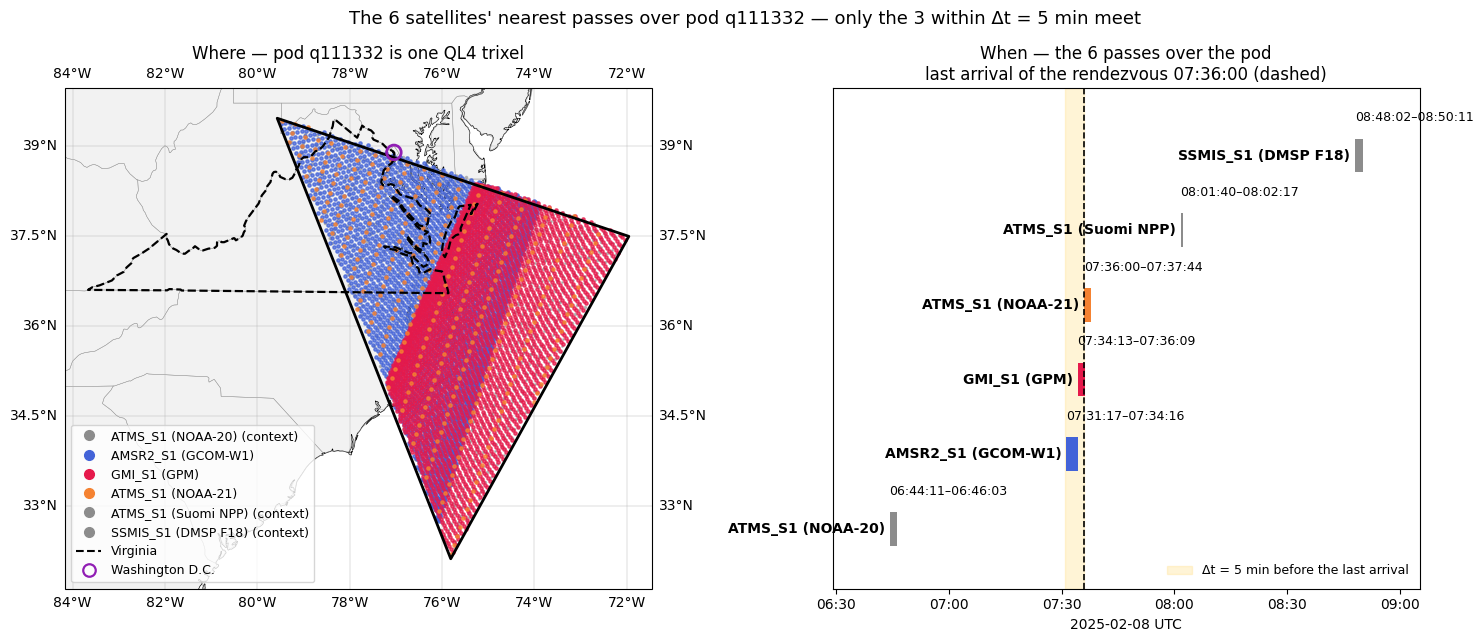

GT(_tbl_data=                swath  data elements pass start  pass end in the rendezvous
0  AMSR2_S1 (GCOM-W1)           3471   07:31:17  07:34:16                 ✓
1        GMI_S1 (GPM)           3096   07:34:13  07:36:09                 ✓
2   ATMS_S1 (NOAA-21)            327   07:36:00  07:37:44                 ✓, _body=<great_tables._gt_data.Body object at 0x154455b50>, _boxhead=Boxhead([ColInfo(var='swath', type=<ColInfoTypeEnum.default: 1>, column_label='Swath', column_align='left', column_width=None), ColInfo(var='data elements', type=<ColInfoTypeEnum.default: 1>, column_label='Data in S1', column_align='right', column_width=None), ColInfo(var='pass start', type=<ColInfoTypeEnum.default: 1>, column_label='Pass start', column_align='right', column_width=None), ColInfo(var='pass end', type=<ColInfoTypeEnum.default: 1>, column_label='Pass end', column_align='right', column_width=None), ColInfo(var='in the rendezvous', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Missing by<br>(min)'), column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x173297b30>, _spanners=Spanners([]), _heading=Heading(title='Pod q111332 — a 3-Way Rendezvous', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x156311a90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1563104a0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x1578bac90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x173294590>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value

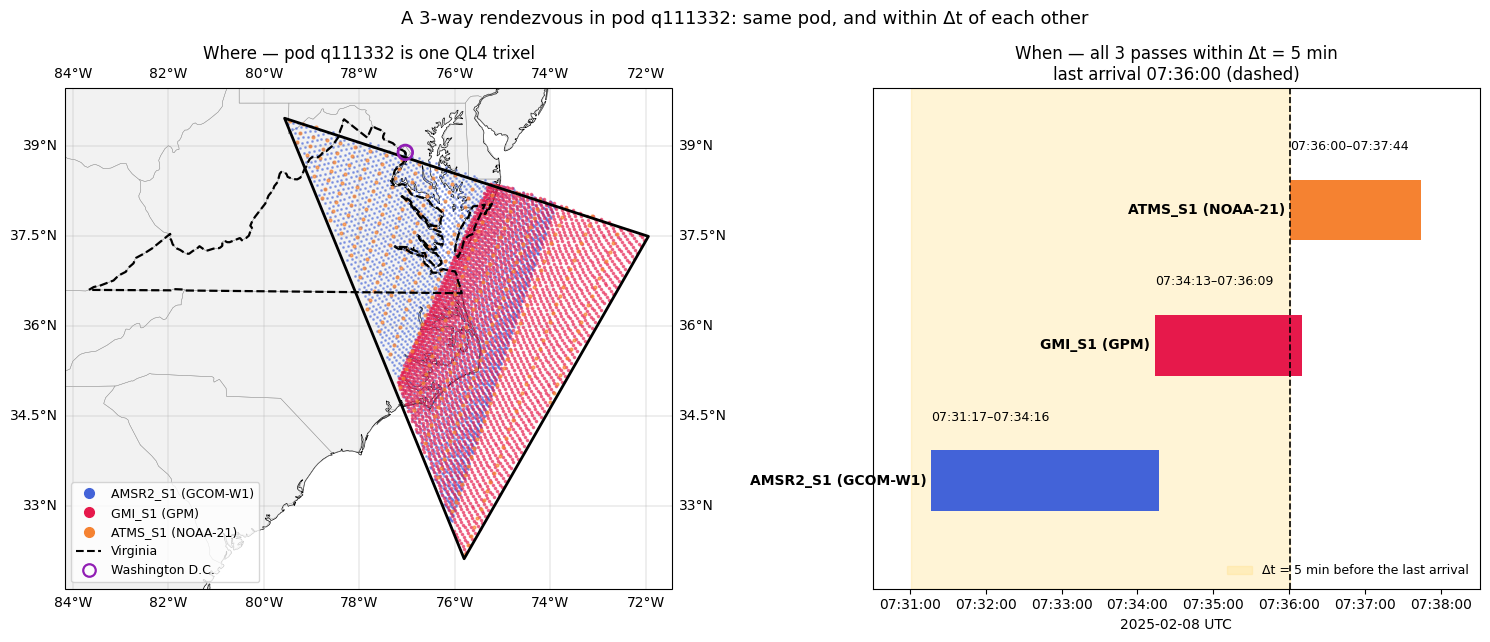

GT(_tbl_data=       kind                                               step   seconds  \
0  download  read the 6 S1 chunks from S3 (Parquet) — all 6...  2.980616   
1   display  render the arrival table — all 6 orbit swaths ...  0.008185   
2      plot     build figure 4 — all 6 orbit swaths in the pod  0.073582   
3   display                                    render figure 4  5.545122   
4  download  read the 3 S1 chunks from S3 (Parquet) — the 3...  1.190679   
5   display  render the arrival table — the 3 swaths of the...  0.007049   
6      plot    build figure 5 — the 3 swaths of the rendezvous  0.054637   
7   display                                    render figure 5  0.156055   

      share  
0  0.297588  
1  0.000817  
2  0.007347  
3  0.553630  
4  0.118879  
5  0.000704  
6  0.005455  
7  0.015581  , _body=<great_tables._gt_data.Body object at 0x17409c860>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x174078710>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 4 Cell', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x174390a40>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x174390530>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x174393050>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1743d20f0>, <great_tables._gt_data.FormatInfo object at 0x17412cda0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='

⏱  cell [6] took 10.03s


In [6]:
T = StepTimer()
from starepandas.demo_plots import swath_label
pod_s1 = in_pod[in_pod['Dataset'].str.endswith('_S1')]             # first scan group of the six swaths
granule_of = {swath_label(d, g): g for d, g in zip(pod_s1['Dataset'], pod_s1['granule'])}
assert len(granule_of) == pod_s1['granule'].nunique()               # one label per swath
cases = [
    (pod_s1,
     f"all {pod_s1['granule'].nunique()} orbit swaths in the pod",
     f"The {pod_s1['granule'].nunique()} satellites' nearest passes over pod {focus_pod} — "
     f"only the {len(members)} within Δt = {minutes_of(EXAMPLE_DT)} min meet"),
    (pod_s1[pod_s1['granule'].isin(members)],
     f"the {len(members)} swaths of the rendezvous", None),
]
for k, (rows, what, title) in enumerate(cases, start=4):
    with T.step('download', f'read the {len(rows)} S1 chunks from S3 (Parquet) — {what}'):
        passes = swath_pixels(demo, rows, span)             # one entry per orbit swath
    member_labels = {label for label in passes if granule_of[label] in members}
    members_start = min(passes[label]['timestamp'].min() for label in member_labels)
    members_end = max(passes[label]['timestamp'].max() for label in member_labels)

    def gap_minutes(px):
        # the rule: a pass joins if it begins no more than Δt after an earlier
        # member's pass ended (or while one is still running) — so an outside
        # pass's gap is measured from the members' passes, not from the meeting
        if px['timestamp'].max() < members_start:
            return (px['timestamp'].max() - members_start).total_seconds() / 60
        if px['timestamp'].min() > members_end:
            return (px['timestamp'].min() - members_end).total_seconds() / 60
        return 0.0

    # one membership column: ✓ for a member, else the pass's gap to the
    # rendezvous in minutes (negative before it, positive after)
    arrival = pd.DataFrame([
        {'swath': label,
         'data elements': len(px),
         'pass start': px['timestamp'].min().strftime('%H:%M:%S'),
         'pass end': px['timestamp'].max().strftime('%H:%M:%S'),
         'in the rendezvous': '✓' if label in member_labels else f"{gap_minutes(px):+.0f}"}
        for label, px in passes.items()
    ])
    with T.step('display', f'render the arrival table — {what}'):
        display(
            GT(arrival)
            .tab_header(title=(f"Pod {focus_pod} — a {len(passes)}-Way Rendezvous" if title is None
                               else f"Pod {focus_pod} — All {len(passes)} Orbit Swaths in the Pod"))
            .fmt_integer(columns='data elements')
            .cols_label(**{'data elements': 'Data in S1',
                           'in the rendezvous': html("Missing by<br>(min)")})
        )
    with T.step('plot', f'build figure {k} — {what}'):
        fig = plot_rendezvous(focus_pod, passes, meeting, EXAMPLE_DT, title=title,
                              region=virginia, region_label='Virginia',
                              point=(DC['lon'], DC['lat']), point_label='Washington D.C.',
                              members=member_labels if title is not None else None,
                              shade_window=True)
    with T.step('display', f'render figure {k}'):
        display(fig)
        plt.close(fig)
display(T.table("Processing Time of Each Step in this Part 4 Cell"))


## Part 5 — Rendezvous over a region of interest

Part 5 asks an operational question: *what did all four instruments observe
over **Virginia** during the six hours surrounding the selected rendezvous?*
The query combines a spatial constraint — the state boundary — with a
temporal constraint. STARE represents Virginia as the cover of four QL4 pods
introduced in Part 3, and the catalog intersects those pod codes with the
six-hour interval. Only the matching Parquet chunks are then read from S3;
swaths outside Virginia or outside the time interval are never scanned.

The selectivity is visible in the counts. The spatial condition alone returns
all catalog records associated with Virginia during the quarter, while the
temporal condition alone returns records worldwide during the six-hour
interval. Their intersection reduces the result to **128 chunks from 11 orbit
swaths**. For the figure's timeline the spatial pick is narrowed to the query
day, so the six-hour period's cut is visible: the chunks it keeps beside
those it drops, hatched. The figure shows the returned data elements above
Virginia's outline and its four cover pods, and, below, the time span of
every first-scan-group chunk the spatial criterion picked that day. Because
retrieval is performed at QL4-pod granularity —
this demonstration's storage and initial-query level — some returned data
extend beyond the state boundary: whole chunks are retrieved during this
initial selection. The tables report all scan groups, whereas the figure
displays the first scan group from each instrument, so it draws fewer chunks
than the tables count. If needed, the hierarchical STARE indices — each
deeper level halving the characteristic linear scale — can support
finer-resolution filtering after this efficient initial selection.


GT(_tbl_data=           criterion                                              value
0   Region (spatial)  the state of Virginia → 4 QL4 cover trixels → ...
1  Period (temporal)  2025-02-08 04:36:00 → 10:36:00 UTC — the Part ..., _body=<great_tables._gt_data.Body object at 0x1743dd7f0>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x17414c5c0>, _spanners=Spanners([]), _heading=Heading(title='The Region-of-Interest Query', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x17412fc50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x17412cd40>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x17412cda0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8

GT(_tbl_data=                                           criterion  chunks
0  Temporal only — everything in the six hours, a...   38574
1   Spatial only — Virginia, any time in the quarter   20216
2             Spatial only — Virginia, the query day     252
3     Spatial AND temporal — Virginia, the six hours     128, _body=<great_tables._gt_data.Body object at 0x3526170b0>, _boxhead=Boxhead([ColInfo(var='criterion', type=<ColInfoTypeEnum.default: 1>, column_label='Criterion', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3526163f0>, _spanners=Spanners([]), _heading=Heading(title='One Query, Both Criteria — the Whole Store', subtitle=Html(text='<b>128 chunks of 11 orbit swaths match both criteria</b> — in 4 of the 4 cover pods'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3526172f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x352617710>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x352617680>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3526174d0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_b

GT(_tbl_data=  instrument  satellite  swaths  chunks          first_start  \
0      AMSR2    GCOM-W1       1      24  2025-02-08 07:29:45   
1       ATMS    NOAA-20       2      20  2025-02-08 06:42:32   
2       ATMS    NOAA-21       2      28  2025-02-08 05:54:00   
3       ATMS  Suomi NPP       2      32  2025-02-08 06:19:40   
4        GMI        GPM       2       8  2025-02-08 07:33:34   
5      SSMIS   DMSP F18       2      16  2025-02-08 08:47:22   

              last_end  
0  2025-02-08 07:34:24  
1  2025-02-08 08:25:23  
2  2025-02-08 07:37:44  
3  2025-02-08 08:03:21  
4  2025-02-08 09:11:07  
5  2025-02-08 10:31:13  , _body=<great_tables._gt_data.Body object at 0x352617080>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.default: 1>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='satellite', type=<ColInfoTypeEnum.default: 1>, column_label='Satellite', column_align='left', column_width=None), ColInfo(var='swaths', type=<ColInfoTypeEnum.default: 1>, column_label='Swaths', column_align='right', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='first_start', type=<ColInfoTypeEnum.default: 1>, column_label='First t_start', column_align='right', column_width=None), ColInfo(var='last_end', type=<ColInfoTypeEnum.default: 1>, column_label='Last t_end', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x352616930>, _spanners=Spanners([]), _heading=Heading(title='Chunks Matching Both Criteria, by Instrument and Satellite', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x352617650>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x352617fe0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x352617b00>, _formats=[<great_tables._gt_data.FormatInfo object at 0x352615070>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top

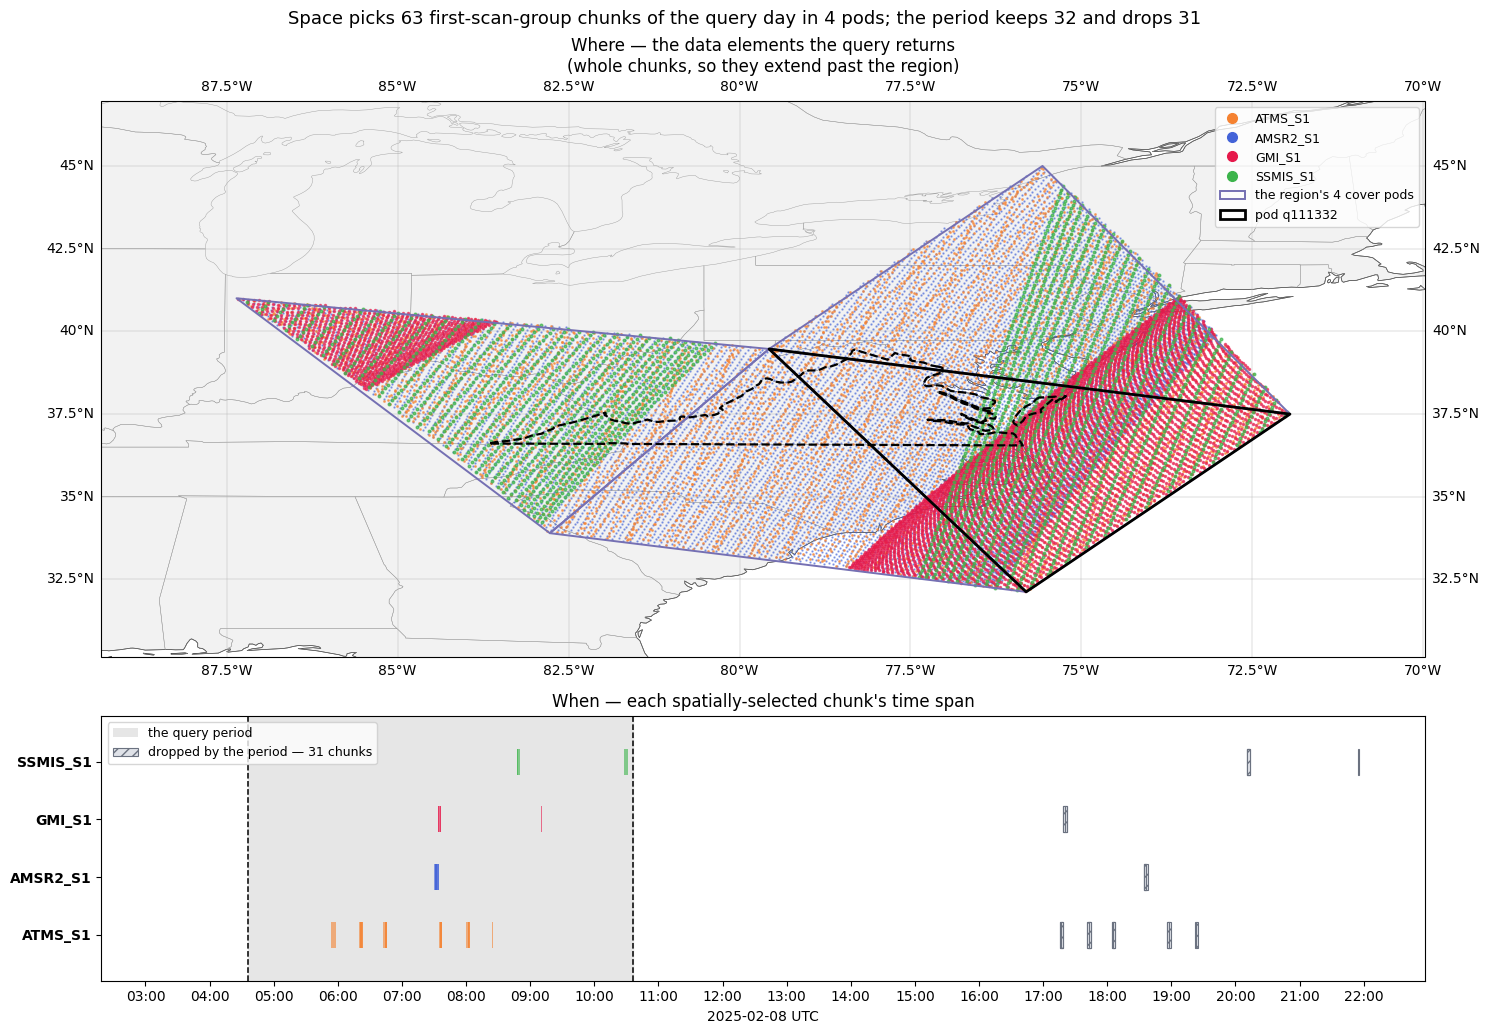

GT(_tbl_data=        kind                                               step    seconds  \
0    display                             render the query table   0.003936   
1      query  spatial only, whole quarter — 4 pod-code catal...   8.954528   
2      local  restrict the spatial pick to the query day (fo...   0.001610   
3      query  temporal only — the whole catalog inside the w...   1.706115   
4      query  spatial AND temporal — the region query, whole...   8.619727   
5    display                          render the criteria table   0.004599   
6    display                       the selectivity, in one line   0.000513   
7      local  keep the first scan group of each instrument f...   0.001146   
8      local  chunks matching both criteria, per instrument ...   0.003081   
9    display                     render the per-satellite table   0.006802   
10  download   read the 32 matching S1 chunks from S3 (Parquet)  14.241720   
11      plot  build figure 6 — S1 data elements + the query ...   0.103878   
12   display                                    render figure 6   0.202865   

       share  
0   0.000116  
1   0.264531  
2   0.000048  
3   0.050401  
4   0.254641  
5   0.000136  
6   0.000015  
7   0.000034  
8   0.000091  
9   0.000201  
10  0.420724  
11  0.003069  
12  0.005993  , _body=<great_tables._gt_data.Body object at 0x341708410>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x174077170>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 5 Cell', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x341e83380>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x341e835f0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x341e83950>, _formats=[<great_tables._gt_data.FormatInfo object at 0x341e83170>, <great_tables._gt_data.FormatInfo object at 0x341e82e40>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(s

⏱  cell [7] took 33.86s


In [7]:
T = StepTimer()
REGION_DT = pd.Timedelta(hours=3)                        # ± around the rendezvous: a six-hour window
window = (meeting - REGION_DT, meeting + REGION_DT)
query = pd.DataFrame([
    {'criterion': 'Region (spatial)',
     'value': f"the state of Virginia → {len(va_sids)} QL{STARE_LEVEL} cover trixels "
              f"→ pods {', '.join(va_pods)}"},
    {'criterion': 'Period (temporal)',
     'value': f"{window[0].strftime('%Y-%m-%d %H:%M:%S')} → {window[1].strftime('%H:%M:%S')} UTC "
              f"— the Part 3 rendezvous ± {REGION_DT.components.hours} h"},
])
with T.step('display', 'render the query table'):
    display(
        GT(query)
        .tab_header(title="The Region-of-Interest Query")
        .cols_label(criterion="", value="")
    )

with T.step('query', f'spatial only, whole quarter — {len(va_pods)} pod-code catalog reads'):
    spatial_q = pd.concat([load_s3_temporal_catalog(podcode_prefix=p) for p in va_pods],
                          ignore_index=True)
with T.step('local', 'restrict the spatial pick to the query day (for the timeline)'):
    day = (window[0].normalize(), window[0].normalize() + pd.Timedelta(days=1))
    spatial_day = spatial_q[(spatial_q['t_start'] <= day[1]) & (spatial_q['t_end'] >= day[0])]
with T.step('query', 'temporal only — the whole catalog inside the window'):
    temporal_q = load_s3_metadata(period=window)
with T.step('query', 'spatial AND temporal — the region query, whole catalog'):
    both_q = demo.find_intersecting_data(va_sids, INSTRUMENTS, period=window)
    both_q['granule'] = [parse_chunk_filename(p)[1] for p in both_q['group_path']]
    both_q['instrument'] = both_q['Dataset'].map(fold_instrument)
    both_q['satellite'] = both_q['granule'].str.split('.').str[1].map(SWATH_SATELLITES)

criteria_q = pd.DataFrame([
    {'criterion': 'Temporal only — everything in the six hours, anywhere on Earth',
     'chunks': len(temporal_q)},
    {'criterion': 'Spatial only — Virginia, any time in the quarter', 'chunks': len(spatial_q)},
    {'criterion': 'Spatial only — Virginia, the query day', 'chunks': len(spatial_day)},
    {'criterion': 'Spatial AND temporal — Virginia, the six hours', 'chunks': len(both_q)},
])
with T.step('display', 'render the criteria table'):
    display(
        GT(criteria_q)
        .tab_header(title="One Query, Both Criteria — the Whole Store",
                    subtitle=html(f"<b>{len(both_q):,} chunks of {both_q['granule'].nunique()} orbit swaths "
                                  f"match both criteria</b> — in {both_q['podcode'].nunique()} of the "
                                  f"{len(va_pods)} cover pods"))
        .fmt_integer(columns='chunks')
    )
with T.step('display', 'the selectivity, in one line'):
    display(HTML('<div align="center"><p style="margin:0.8em 0"><b>'
                 f"Temporal only {len(temporal_q):,} chunks · spatial only {len(spatial_q):,} → "
                 f"spatial AND temporal {len(both_q):,}</b></p></div>"))
with T.step('local', 'keep the first scan group of each instrument for the figure'):
    both_q_s1 = both_q[both_q['Dataset'].str.endswith('_S1')]
    spatial_day_s1 = spatial_day[spatial_day['Dataset'].str.endswith('_S1')]

with T.step('local', 'chunks matching both criteria, per instrument and satellite (pandas)'):
    per_sat = (both_q.groupby(['instrument', 'satellite'])
               .agg(swaths=('granule', 'nunique'), chunks=('podcode', 'size'),
                    first_start=('t_start', 'min'), last_end=('t_end', 'max'))
               .reset_index())
with T.step('display', 'render the per-satellite table'):
    display(
        GT(fmt_times(per_sat, ('first_start', 'last_end')))
        .tab_header(title="Chunks Matching Both Criteria, by Instrument and Satellite")
        .fmt_integer(columns='chunks')
        .cols_label(swaths="Swaths", chunks="Chunks",
                    first_start="First t_start", last_end="Last t_end")
    )

with T.step('download', f'read the {len(both_q_s1)} matching S1 chunks from S3 (Parquet)'):
    region_passes_q = chunk_pixels(demo, both_q_s1, window, fold=False)
with T.step('plot', 'build figure 6 — S1 data elements + the query day\'s S1 chunk timeline'):
    fig = plot_region_result(region_passes_q, spatial_day_s1, window, bbox=None,
                             region=virginia, highlight_pod=focus_pod, fold=False,
                             subject='first-scan-group chunks of the query day',
                             cover_pods=va_pods)
with T.step('display', 'render figure 6'):
    display(fig)
    plt.close(fig)
display(T.table("Processing Time of Each Step in this Part 5 Cell"))


## Part 6 — Performance at scale

Part 6 benchmarks the rendezvous workflow as the temporal scope expands from
one day to one week, one month, and the full quarter, on the same
whole-store catalog as Parts 1–5 — about 7,400 granules and 12.5 million
Parquet chunks. At each scope, it measures three stages: retrieving four
fields from the catalog, searching each QL4 pod's records in time order, and
aggregating the results into the instrument-pair matrix and per-pod summary.
All four scopes use Δt = 10 min, Part 2's matrix window; the quarter row
therefore reproduces Part 2's pair matrix exactly — shown last, as the
cross-check.

The benchmark separates metadata discovery from science-data access: no
Parquet chunk is opened, and S3 is not read. The timings are those observed
in this single demonstration run — they include fixed overhead, caching and
network conditions, so they are evidence of scale rather than a scaling law. The
same ordered pass produces the 2-, 3- and 4-way results simultaneously: **one
catalog pass computes all of them**, and the workflow performs no separate
pairwise join for every instrument combination. The result demonstrates that
STARE-PODS can screen a quarter-scale, multi-instrument catalog efficiently
and defer payload access until relevant observations have been identified.


In [8]:
T = StepTimer()
PART6_DT = WINDOWS[1]                           # 10 min, as Part 2's matrix
PART6_MIN = minutes_of(PART6_DT)
SCOPES = [
    ('one day (Feb 8)',     (pd.Timestamp('2025-02-08'), pd.Timestamp('2025-02-09'))),
    ('one week (Feb 8–14)', (pd.Timestamp('2025-02-08'), pd.Timestamp('2025-02-15'))),
    ('one month (Feb)',     (pd.Timestamp('2025-02-01'), pd.Timestamp('2025-03-01'))),
    ('the quarter',         None),
]
perf_rows = []
for label, period in SCOPES:
    with T.step('query', f'read 4 catalog columns — {label}'):
        scoped = load_s3_temporal_catalog(period=period)      # the whole store, as Part 2
    t_load = T.last
    with T.step('local', f'find meetings (rendezvous_events) — {label}'):
        ev = rendezvous_events(scoped, PART6_DT)
    t_find = T.last
    with T.step('local', f'aggregate (matrix + pod table) — {label}'):
        mat, tab = overlap_matrix(ev), overlap_pod_table(ev)
    t_agg = T.last
    row = {'scope': label, 'chunks': len(scoped), 'load_s': t_load,
           'find_s': t_find, 'aggregate_s': t_agg, 'events': len(ev)}
    for n in (2, 3, 4):
        row[f'{n}-way'] = int(tab[n].gt(0).sum()) if n in tab.columns else 0
    perf_rows.append(row)
    if period is None:                      # keep the quarter's results
        quarter_events, quarter_matrix, quarter_table = ev, mat, tab
    del scoped
perf = pd.DataFrame(perf_rows)
with T.step('display', 'render the scope × stage table'):
    display(
        GT(perf)
        .tab_header(title=f"The Rendezvous Engine at Scale — the Whole Store, Δt = {PART6_MIN} min")
        .fmt_integer(columns=['chunks', 'events'])
        .fmt_number(columns=['load_s', 'find_s', 'aggregate_s'], decimals=1)
        .tab_spanner(label=spanner("Seconds"), columns=['load_s', 'find_s', 'aggregate_s'])
        .tab_spanner(label=spanner("QL4 Pods with an n-way Rendezvous"),
                     columns=['2-way', '3-way', '4-way'])
        .cols_label(scope="", load_s=html("Catalog<br>read"), find_s=html("Find<br>matches"),
                    aggregate_s="Aggregate")
    )
with T.step('display', "this run's quarter timings, in words"):
    q_row = perf[perf['scope'] == 'the quarter'].iloc[0]
    display(HTML('<div align="center"><p style="margin:0.8em 0"><b>In this run</b>, the full-quarter '
                 f"catalog retrieval took {q_row['load_s']:.0f} s, the rendezvous search "
                 f"{q_row['find_s']:.0f} s and the aggregation {q_row['aggregate_s']:.1f} s.</p></div>"))

with T.step('local', 'split the quarter\'s events by n-way (pandas)'):
    quarter_find_s = perf.loc[perf['scope'] == 'the quarter', 'find_s'].iloc[0]
    widths = quarter_events['instruments'].map(len)
    flat = pd.DataFrame([
        {'width': f'{n}-way',
         'pods': int(quarter_table[n].gt(0).sum()),
         'events': int((widths == n).sum())}
        for n in (2, 3, 4)
    ])   # an event = one pass arriving at a pod while others are still active
with T.step('display', 'render the one-pass table'):
    display(
        GT(flat)
        .tab_header(title="One Catalog Pass Computes All 2-, 3- and 4-Way Results")
        .fmt_integer(columns='events')
        .cols_label(width="", pods="Pods with an n-way", events="Events at n-way")
    )

with T.step('local', 'shape the quarter matrix'):
    assert quarter_matrix.equals(overlap_matrix(q_events))   # the same catalog and window as Part 2
    qm = quarter_matrix.astype(object)
    for instrument in qm.index:
        qm.loc[instrument, instrument] = '—'
    qm.insert(0, 'instrument', qm.index)
with T.step('display', 'render the quarter matrix'):
    display(
        GT(qm.reset_index(drop=True), rowname_col='instrument')
        .tab_header(title="Who Met Whom over 2025Q1")
    )
display(T.table("Processing Time of Each Step in this Part 6 Cell"))


GT(_tbl_data=                 scope    chunks     load_s     find_s  aggregate_s   events  \
0      one day (Feb 8)    149621   1.577533   0.118835     0.032070    25749   
1  one week (Feb 8–14)   1032897   5.237485   0.872034     0.159137   208053   
2      one month (Feb)   4142972  15.610252   3.685509     0.532948   835684   
3          the quarter  12451867  38.586122  12.454923     1.419840  2338290   

   2-way  3-way  4-way  
0   2010    359      6  
1   2048   1211     12  
2   2048   1747     35  
3   2048   1983     65  , _body=<great_tables._gt_data.Body object at 0x341432a20>, _boxhead=Boxhead([ColInfo(var='scope', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='chunks', type=<ColInfoTypeEnum.default: 1>, column_label='Chunks', column_align='right', column_width=None), ColInfo(var='load_s', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Catalog<br>read'), column_align='right', column_width=None), ColInfo(var='find_s', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Find<br>matches'), column_align='right', column_width=None), ColInfo(var='aggregate_s', type=<ColInfoTypeEnum.default: 1>, column_label='Aggregate', column_align='right', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events', column_align='right', column_width=None), ColInfo(var='2-way', type=<ColInfoTypeEnum.default: 1>, column_label='2-way', column_align='right', column_width=None), ColInfo(var='3-way', type=<ColInfoTypeEnum.default: 1>, column_label='3-way', column_align='right', column_width=None), ColInfo(var='4-way', type=<ColInfoTypeEnum.default: 1>, column_label='4-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x341430e60>, _spanners=Spanners([SpannerInfo(spanner_id='<div align="center">Seconds</div>', spanner_level=0, spanner_label=Html(text='<div align="center">Seconds</div>'), spanner_units=None, spanner_pattern=None, vars=['load_s', 'find_s', 'aggregate_s'], built=None), SpannerInfo(spanner_id='<div align="center">QL4 Pods with an n-way Rendezvous</div>', spanner_level=0, spanner_label=Html(text='<div align="center">QL4 Pods with an n-way Rendezvous</div>'), spanner_units=None, spanner_pattern=None, vars=['2-way', '3-way', '4-way'], built=None)]), _heading=Heading(title='The Rendezvous Engine at Scale — the Whole Store, Δt = 10 min', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x341430a70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3414329f0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x341432d80>, _formats=[<great_tables._gt_data.FormatInfo object at 0x341433200>, <great_tables._gt_data.FormatInfo object at 0x341432e10>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, c

GT(_tbl_data=   width  pods   events
0  2-way  2048  2104183
1  3-way  1983   233532
2  4-way    65      575, _body=<great_tables._gt_data.Body object at 0x3414309e0>, _boxhead=Boxhead([ColInfo(var='width', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='pods', type=<ColInfoTypeEnum.default: 1>, column_label='Pods with an n-way', column_align='right', column_width=None), ColInfo(var='events', type=<ColInfoTypeEnum.default: 1>, column_label='Events at n-way', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x341431610>, _spanners=Spanners([]), _heading=Heading(title='One Catalog Pass Computes All 2-, 3- and 4-Way Results', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x341643560>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3416427b0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x341643d10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x341430290>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', 

GT(_tbl_data=  instrument AMSR2  ATMS   GMI SSMIS
0      AMSR2     —  2048  1976   473
1       ATMS  2048     —  1980   653
2        GMI  1976  1980     —  1963
3      SSMIS   473   653  1963     —, _body=<great_tables._gt_data.Body object at 0x341415640>, _boxhead=Boxhead([ColInfo(var='instrument', type=<ColInfoTypeEnum.stub: 2>, column_label='Instrument', column_align='left', column_width=None), ColInfo(var='AMSR2', type=<ColInfoTypeEnum.default: 1>, column_label='AMSR2', column_align='left', column_width=None), ColInfo(var='ATMS', type=<ColInfoTypeEnum.default: 1>, column_label='ATMS', column_align='left', column_width=None), ColInfo(var='GMI', type=<ColInfoTypeEnum.default: 1>, column_label='GMI', column_align='left', column_width=None), ColInfo(var='SSMIS', type=<ColInfoTypeEnum.default: 1>, column_label='SSMIS', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3414166f0>, _spanners=Spanners([]), _heading=Heading(title='Who Met Whom over 2025Q1', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3414159a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x341414590>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x341417ec0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, 

GT(_tbl_data=       kind                                               step    seconds  \
0     query           read 4 catalog columns — one day (Feb 8)   1.577533   
1     local  find meetings (rendezvous_events) — one day (F...   0.118835   
2     local   aggregate (matrix + pod table) — one day (Feb 8)   0.032070   
3     query       read 4 catalog columns — one week (Feb 8–14)   5.237485   
4     local  find meetings (rendezvous_events) — one week (...   0.872034   
5     local  aggregate (matrix + pod table) — one week (Feb...   0.159137   
6     query           read 4 catalog columns — one month (Feb)  15.610252   
7     local  find meetings (rendezvous_events) — one month ...   3.685509   
8     local   aggregate (matrix + pod table) — one month (Feb)   0.532948   
9     query               read 4 catalog columns — the quarter  38.586122   
10    local    find meetings (rendezvous_events) — the quarter  12.454923   
11    local       aggregate (matrix + pod table) — the quarter   1.419840   
12  display                     render the scope × stage table   0.010681   
13  display               this run's quarter timings, in words   0.000859   
14    local       split the quarter's events by n-way (pandas)   0.396885   
15  display                          render the one-pass table   0.004829   
16    local                           shape the quarter matrix   1.290623   
17  display                          render the quarter matrix   0.006336   

       share  
0   0.019239  
1   0.001449  
2   0.000391  
3   0.063874  
4   0.010635  
5   0.001941  
6   0.190376  
7   0.044947  
8   0.006500  
9   0.470580  
10  0.151895  
11  0.017316  
12  0.000130  
13  0.000010  
14  0.004840  
15  0.000059  
16  0.015740  
17  0.000077  , _body=<great_tables._gt_data.Body object at 0x3414148c0>, _boxhead=Boxhead([ColInfo(var='kind', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='step', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3414178c0>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Step in this Part 6 Cell', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3414d4890>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3414d65a0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3414d5ee0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3414d4fe0>, <great_tables._gt_data.FormatInfo object at 0x3414d68d0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_backgro

⏱  cell [8] took 82.02s


## Recap

In this video we demonstrated a construction of the STARE Parallel Optimized
Data Store, **STARE-PODS**. During the construction, a DBMS is used to
catalog the relevant metadata, and it supports **pod-level rendezvous
analytics** — often the first step in the integrative analysis of diverse
data. These rendezvous can be efficiently refined by leveraging the STARE
hierarchy to obtain data-element-level rendezvous. And the engine scales:
the whole quarter's catalog — twelve million chunk records — reads in well
under a minute and its rendezvous are found in seconds, 2-, 3- and 4-way
alike, without opening a single chunk.

Three messages to take away:

1. **STARE harmonizes** diverse geospatial observations through a common
   hierarchical index while preserving their native geometry — no regridding.
2. **The catalog identifies** relevant observations before costly payload
   access — reducing the Virginia search by more than 600× in this example,
   and applying space and time together to read only the matching chunks.
3. **The same hierarchy supports progressive refinement**, from pod-level
   regional discovery to data-element-level integrative analysis.

Since the Parquet chunks' file names contain the pod codes, and their
contents the spatiotemporal information of the data, rendezvous analytics can
also be performed using the Parquet chunks alone — less efficiently than with
the database, but still better than searching the original granules one by one.


## Run time

Every code cell above reported its own wall-clock time; here is the total
and where it went. A handful of cells account for nearly all of it, and each
is doing a whole quarter's work or opening chunks: the database's one full
read of the 12.5 M-row catalog for the holdings table, Part 2's quarter catalog read and
three meeting searches, Parts 4 and 5's chunk downloads, and Part 6's four
scopes. Everything the rendezvous engine itself does — the meeting searches
of Parts 2, 3 and 6 — is seconds or less. (Parts 4 and 5 are the only
cells that open chunks; the rest is catalog only.) The holdings cell
and Parts 2–6 each end with their own step-by-step breakdown —
query vs. download vs. local compute vs. plotting vs. rendering.


In [9]:
CELL_LABELS = {              # In[n] → what that cell does (cells run in order)
    1: 'setup — imports, config',
    2: 'data ingested in STARE-PODS — quarter summary + occupancy (server-side)',
    3: 'Part 1 — temporal catalog tables',
    4: 'Part 2 — quarter catalog read, Δt searches, matrix, drill-down',
    5: 'Part 3 — Virginia pods: catalog read, cover figure, Δt searches, six swaths (figures 1–3)',
    6: 'Part 4 — the example pod up close: six passes, then the 3-way (figures 4–5, chunk downloads)',
    7: 'Part 5 — the Virginia region query against the whole store (figure 6)',
    8: 'Part 6 — day / week / month / quarter timings',
}
timings = pd.DataFrame({'cell': list(CELL_TIMINGS), 'seconds': list(CELL_TIMINGS.values())})
timings['what'] = timings['cell'].map(CELL_LABELS).fillna('')
total = timings['seconds'].sum()
timings['share'] = timings['seconds'] / total
display(
    GT(timings[['cell', 'what', 'seconds', 'share']])
    .tab_header(title=f"Processing Time of Each Notebook Cell: {total:.0f} s total ({total / 60:.1f} min)")
    .fmt_number(columns='seconds', decimals=1)
    .fmt_percent(columns='share', decimals=0)
    .cols_label(cell="In [n]", what="", seconds="Seconds", share="Share")
    .tab_style(style=style.text(weight='bold'),
               locations=loc.body(columns='seconds',
                                  rows=timings['seconds'].nlargest(2).index.tolist()))
)


GT(_tbl_data=   cell                                               what     seconds  \
0     1                            setup — imports, config    3.836527   
1     2  data ingested in STARE-PODS — quarter summary ...  111.939609   
2     3                   Part 1 — temporal catalog tables    0.052134   
3     4  Part 2 — quarter catalog read, Δt searches, ma...   78.847398   
4     5  Part 3 — Virginia pods: catalog read, cover fi...   17.697198   
5     6  Part 4 — the example pod up close: six passes,...   10.029605   
6     7  Part 5 — the Virginia region query against the...   33.863751   
7     8      Part 6 — day / week / month / quarter timings   82.024816   

      share  
0  0.011341  
1  0.330897  
2  0.000154  
3  0.233076  
4  0.052314  
5  0.029648  
6  0.100102  
7  0.242468  , _body=<great_tables._gt_data.Body object at 0x3413ba1e0>, _boxhead=Boxhead([ColInfo(var='cell', type=<ColInfoTypeEnum.default: 1>, column_label='In [n]', column_align='right', column_width=None), ColInfo(var='what', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Seconds', column_align='right', column_width=None), ColInfo(var='share', type=<ColInfoTypeEnum.default: 1>, column_label='Share', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x341417e90>, _spanners=Spanners([]), _heading=Heading(title='Processing Time of Each Notebook Cell: 338 s total (5.6 min)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3415e1970>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3415e2e70>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocSubTitle(), grpname=None, colname=None, rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align='center', v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='seconds', rows=[1, 7], mask=None), grpname=None, colname='seconds', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='seconds', rows=[1, 7], mask=None), grpname=None, colname='seconds', rownum=7, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x3415e3200>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3415e1790>, <great_tables._gt_data.FormatInfo object at 0x3415e1ca0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Ca

⏱  cell [9] took 0.01s
